# News Category Classification using RNN, LSTM, and GloVe Embeddings

## Language Task Setup and Dataset Configuration

This notebook prepares the coding environment for the Part III language task. The work in this opening section focuses on Google Colab setup, Google Drive configuration, required library installation, dataset path preparation, folder creation, and initial checks on the instructor-assigned `news_category.csv` file before any preprocessing or modelling begins.

In [1]:
# Package setup for text preprocessing, visualization,
# and pretrained embedding support in Google Colab.

import sys

python_version = f"{sys.version_info.major}.{sys.version_info.minor}"
print("Python version:", python_version)

if sys.version_info < (3, 12):
    print("Applying the guide-compatible NumPy downgrade for gensim.")
    !pip install numpy==1.23.5
    !pip install jax==0.4.13 jaxlib==0.4.13
else:
    print("Using the preinstalled NumPy version provided by the current Colab runtime.")
    print("Removing conflicting JAX packages so TensorFlow can import cleanly in Python 3.12 runtimes.")
    !pip uninstall -y jax jaxlib

!pip install gensim
!pip install contractions
!pip install wordcloud


Python version: 3.12
Using the preinstalled NumPy version provided by the current Colab runtime.
Removing conflicting JAX packages so TensorFlow can import cleanly in Python 3.12 runtimes.
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.3 MB/s eta 0:00:00


This cell installs the libraries required for the language-task workflow that may not already be available in a fresh Colab environment. The package setup is included at the beginning so that the later preprocessing, visualization, and embedding sections can run in a consistent software environment.

## Environment Compatibility Note

*The package installation is followed by a runtime restart in Colab so that the resolved library versions are loaded consistently before the later notebook sections begin. This helps ensure that the imported libraries reflect the package state established in the setup cell.*

In [1]:
import gc
import json
import os
import pickle
import random
import re
import time
from pathlib import Path

import contractions
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from wordcloud import WordCloud


These imports prepare the notebook for the full language-task workflow. Although preprocessing and modelling do not begin in this section, importing the core libraries at the start confirms that the environment has been configured correctly following the compatibility setup.


In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

These NLTK downloads provide the language resources needed later for tokenization, stopword removal, and lemmatization. In Colab, these resources are often session-specific, so downloading them at the beginning improves reproducibility.


In [73]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive



This cell mounts Google Drive so that the notebook can access the instructor-assigned dataset and save all later outputs, including checkpoints, figures, histories, tables, and serialized preprocessing objects, to persistent storage.

In [74]:
DATASET_ROOT = Path("/content/drive/MyDrive") / "News-dataset"
DATASET_FILE = DATASET_ROOT / "news_category.csv"

PROJECT_OUTPUT_ROOT = DATASET_ROOT / "news_category_outputs"
CHECKPOINT_DIR = DATASET_ROOT / "checkpoints"
FIGURE_DIR = PROJECT_OUTPUT_ROOT / "figures"
HISTORY_DIR = PROJECT_OUTPUT_ROOT / "histories"
METRIC_DIR = PROJECT_OUTPUT_ROOT / "metrics"
TABLE_DIR = PROJECT_OUTPUT_ROOT / "tables"
OBJECT_DIR = PROJECT_OUTPUT_ROOT / "objects"
GUI_DIR = PROJECT_OUTPUT_ROOT / "gui"

TEXT_COLUMN = "headline"
LABEL_COLUMN = "category"

EXPECTED_RAW_ROWS = 11025
EXPECTED_RAW_COLUMNS = 2
EXPECTED_DUPLICATES = 78
EXPECTED_FINAL_ROWS_AFTER_DEDUP = 10947
EXPECTED_NULL_VALUES = 0
EXPECTED_CLASSES = [
    "CULTURE & ARTS",
    "EDUCATION",
    "MONEY",
    "SPORTS",
    "TECH",
]
EXPECTED_NUM_CLASSES = 5

RANDOM_STATE = 42
TEST_SIZE = 0.20
NUM_WORDS = 10000
MAX_LENGTH = 15
NUM_CLASSES = 5
EMBEDDING_DIM = 64
GLOVE_EMBEDDING_DIM = 50
RNN_UNITS = 64
LSTM_UNITS = 64
BATCH_SIZE = 32
EPOCHS = 50


This configuration cell defines the dataset folder using the actual mounted Google Drive location for `News-dataset`. The dataset file is read from that location, and all checkpoints and outputs are also stored within the same folder so that the project remains organized and self-contained in Google Drive.


In [75]:
TOKENIZER_PATH = OBJECT_DIR / "tokenizer.pkl"
LABEL_ENCODER_PATH = OBJECT_DIR / "label_encoder.pkl"
X_TRAIN_PAD_PATH = OBJECT_DIR / "X_train_pad.npy"
X_TEST_PAD_PATH = OBJECT_DIR / "X_test_pad.npy"
Y_TRAIN_RAW_PATH = OBJECT_DIR / "y_train_raw.npy"
Y_TEST_RAW_PATH = OBJECT_DIR / "y_test_raw.npy"
EMBEDDING_MATRIX_GLOVE50_PATH = OBJECT_DIR / "embedding_matrix_glove50.npy"

MODEL1_CHECKPOINT_PATH = CHECKPOINT_DIR / "model1_rnn_best.keras"
MODEL2_CHECKPOINT_PATH = CHECKPOINT_DIR / "model2_lstm_best.keras"
MODEL3_CHECKPOINT_PATH = CHECKPOINT_DIR / "model3_lstm_glove_best.keras"

HISTORY_RNN_PATH = HISTORY_DIR / "history_rnn.json"
HISTORY_LSTM_PATH = HISTORY_DIR / "history_lstm.json"
HISTORY_GLOVE_PATH = HISTORY_DIR / "history_glove.json"

MODEL1_REPORT_PATH = METRIC_DIR / "model1_rnn_classification_report.txt"
MODEL2_REPORT_PATH = METRIC_DIR / "model2_lstm_classification_report.txt"
MODEL3_REPORT_PATH = METRIC_DIR / "model3_lstm_glove_classification_report.txt"

CLASS_DISTRIBUTION_TABLE_PATH = TABLE_DIR / "class_distribution.csv"
MODEL_COMPARISON_TABLE_PATH = TABLE_DIR / "model_comparison.csv"
PER_CLASS_F1_TABLE_PATH = TABLE_DIR / "per_class_f1_comparison.csv"
MISCLASSIFIED_EXAMPLES_PATH = TABLE_DIR / "misclassified_examples.csv"

CLASS_DISTRIBUTION_FIG_PATH = FIGURE_DIR / "class_distribution.png"
HEADLINE_LENGTH_FIG_PATH = FIGURE_DIR / "headline_length_distribution.png"
WORDCLOUD_ALL_FIG_PATH = FIGURE_DIR / "wordcloud_all.png"
WORDCLOUD_PER_CLASS_FIG_PATH = FIGURE_DIR / "wordcloud_per_class.png"
TOP_WORDS_FIG_PATH = FIGURE_DIR / "top_words_frequency.png"
MODEL1_LOSS_FIG_PATH = FIGURE_DIR / "model1_rnn_loss_curve.png"
MODEL1_ACCURACY_FIG_PATH = FIGURE_DIR / "model1_rnn_accuracy_curve.png"
MODEL1_CONFUSION_FIG_PATH = FIGURE_DIR / "model1_rnn_confusion_matrix.png"
MODEL2_LOSS_FIG_PATH = FIGURE_DIR / "model2_lstm_loss_curve.png"
MODEL2_ACCURACY_FIG_PATH = FIGURE_DIR / "model2_lstm_accuracy_curve.png"
RNN_VS_LSTM_LOSS_FIG_PATH = FIGURE_DIR / "rnn_vs_lstm_loss_overlay.png"
RNN_VS_LSTM_ACCURACY_FIG_PATH = FIGURE_DIR / "rnn_vs_lstm_accuracy_overlay.png"
MODEL2_CONFUSION_FIG_PATH = FIGURE_DIR / "model2_lstm_confusion_matrix.png"
MODEL3_LOSS_FIG_PATH = FIGURE_DIR / "model3_lstm_glove_loss_curve.png"
MODEL3_ACCURACY_FIG_PATH = FIGURE_DIR / "model3_lstm_glove_accuracy_curve.png"
MODEL3_CONFUSION_FIG_PATH = FIGURE_DIR / "model3_lstm_glove_confusion_matrix.png"
ALL_MODELS_VAL_ACCURACY_FIG_PATH = FIGURE_DIR / "all_models_val_accuracy_overlay.png"
PER_CLASS_F1_FIG_PATH = FIGURE_DIR / "per_class_f1_comparison.png"


This cell defines the main save locations that will be used in the later notebook sections. Although these files are not created yet during setup, declaring the paths early keeps the project structure clear and makes the output locations explicit.


In [76]:
def ensure_directory(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def get_gpu_name() -> str:
    gpu_devices = tf.config.list_physical_devices("GPU")
    if not gpu_devices:
        return "CPU only"

    try:
        details = tf.config.experimental.get_device_details(gpu_devices[0])
        return details.get("device_name", "GPU detected")
    except Exception:
        return "GPU detected"


def print_path_status(label: str, path: Path) -> None:
    print(f"{label}: {path}")
    print(f"Exists: {path.exists()}")


def set_random_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


These helper functions keep the setup section concise and readable. They manage folder creation, GPU-name retrieval, path-status reporting, and random-seed configuration so that the later setup checks remain straightforward to interpret.


In [77]:
for directory in [
    PROJECT_OUTPUT_ROOT,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    HISTORY_DIR,
    METRIC_DIR,
    TABLE_DIR,
    OBJECT_DIR,
    GUI_DIR,
]:
    ensure_directory(directory)

set_random_seeds(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("GPU active:", bool(tf.config.list_physical_devices("GPU")))
print("GPU name:", get_gpu_name())
print()

print_path_status("Dataset root", DATASET_ROOT)
print_path_status("Dataset file", DATASET_FILE)
print_path_status("Project output root", PROJECT_OUTPUT_ROOT)
print_path_status("Checkpoint directory", CHECKPOINT_DIR)
print_path_status("Figure directory", FIGURE_DIR)
print_path_status("History directory", HISTORY_DIR)
print_path_status("Metric directory", METRIC_DIR)
print_path_status("Table directory", TABLE_DIR)
print_path_status("Object directory", OBJECT_DIR)
print_path_status("GUI directory", GUI_DIR)
print()

print("Random state:", RANDOM_STATE)
print("Test split:", TEST_SIZE)
print("NUM_WORDS:", NUM_WORDS)
print("MAX_LENGTH:", MAX_LENGTH)
print("NUM_CLASSES:", NUM_CLASSES)
print("EMBEDDING_DIM:", EMBEDDING_DIM)
print("GLOVE_EMBEDDING_DIM:", GLOVE_EMBEDDING_DIM)
print("RNN_UNITS:", RNN_UNITS)
print("LSTM_UNITS:", LSTM_UNITS)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)


TensorFlow version: 2.20.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU active: True
GPU name: Tesla T4

Dataset root: /content/drive/MyDrive/News-dataset
Exists: True
Dataset file: /content/drive/MyDrive/News-dataset/news_category.csv
Exists: True
Project output root: /content/drive/MyDrive/News-dataset/news_category_outputs
Exists: True
Checkpoint directory: /content/drive/MyDrive/News-dataset/checkpoints
Exists: True
Figure directory: /content/drive/MyDrive/News-dataset/news_category_outputs/figures
Exists: True
History directory: /content/drive/MyDrive/News-dataset/news_category_outputs/histories
Exists: True
Metric directory: /content/drive/MyDrive/News-dataset/news_category_outputs/metrics
Exists: True
Table directory: /content/drive/MyDrive/News-dataset/news_category_outputs/tables
Exists: True
Object directory: /content/drive/MyDrive/News-dataset/news_category_outputs/objects
Exists: True
GUI directory: /content/drive/MyDrive/New

This cell creates the output folders, fixes the random seeds, and prints the runtime and path configuration. Its output reports whether a GPU is active, whether the dataset file is present in Google Drive, and whether all required output directories have been created successfully.


## Dataset Loading and Initial Inspection

The following cells verify that the correct CSV file is available and confirm the raw dataset structure before any rows are removed or transformed.


In [78]:
df = pd.read_csv(DATASET_FILE)

print("Raw dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 10 rows:")
display(df.head(10))


Raw dataset shape: (11025, 2)

Column names:
['headline', 'category']

Data types:
headline    object
category    object
dtype: object

First 10 rows:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


This cell loads the instructor-assigned dataset directly from Google Drive and prints the raw shape, column names, data types, and the first 10 rows. The expected raw structure is `11,025` rows and `2` columns, with `headline` as the text field and `category` as the label field.

In [79]:
null_summary = df.isnull().sum()
duplicate_count = int(df.duplicated().sum())
class_counts_raw = df[LABEL_COLUMN].value_counts().sort_index()
unique_classes_sorted = sorted(df[LABEL_COLUMN].unique().tolist())

print("Null values per column:")
print(null_summary)
print("\nDuplicate row count:")
print(duplicate_count)
print("\nRaw class distribution:")
print(class_counts_raw)
print("\nUnique classes:")
print(unique_classes_sorted)

if list(df.columns) != [TEXT_COLUMN, LABEL_COLUMN]:
    raise ValueError(
        f"Unexpected columns found: {df.columns.tolist()}. "
        f"Expected [{TEXT_COLUMN!r}, {LABEL_COLUMN!r}]."
    )

if df.shape != (EXPECTED_RAW_ROWS, EXPECTED_RAW_COLUMNS):
    raise ValueError(
        f"Unexpected raw shape: {df.shape}. "
        f"Expected {(EXPECTED_RAW_ROWS, EXPECTED_RAW_COLUMNS)}."
    )

if int(null_summary.sum()) != EXPECTED_NULL_VALUES:
    raise ValueError(
        f"Unexpected null count: {int(null_summary.sum())}. "
        f"Expected {EXPECTED_NULL_VALUES}."
    )

if duplicate_count != EXPECTED_DUPLICATES:
    raise ValueError(
        f"Unexpected duplicate count: {duplicate_count}. "
        f"Expected {EXPECTED_DUPLICATES}."
    )

if unique_classes_sorted != EXPECTED_CLASSES:
    raise ValueError(
        f"Unexpected class labels: {unique_classes_sorted}. "
        f"Expected {EXPECTED_CLASSES}."
    )

print("\nInitial dataset checks passed successfully.")


Null values per column:
headline    0
category    0
dtype: int64

Duplicate row count:
78

Raw class distribution:
category
CULTURE & ARTS    1074
EDUCATION         1014
MONEY             1756
SPORTS            5077
TECH              2104
Name: count, dtype: int64

Unique classes:
['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']

Initial dataset checks passed successfully.


This cell performs the main verification checks required before preprocessing begins. It confirms the expected columns, raw shape, null-value count, duplicate count, and the five target classes. Any mismatch at this stage indicates that the dataset does not yet align with the expected project specification.


In [80]:
task_setup_summary = pd.DataFrame(
    {
        "Item": [
            "Task type",
            "Dataset folder",
            "Dataset file",
            "Text column",
            "Label column",
            "Number of classes",
            "Classes",
            "Duplicate rows to remove later",
            "Expected final rows after deduplication",
            "Problem type",
            "Output activation",
            "Loss function",
            "Train-test split",
            "Split strategy",
            "Tokenizer fitting rule",
            "NUM_WORDS",
            "MAX_LENGTH",
        ],
        "Value": [
            "Multi-class news category classification",
            DATASET_ROOT.name,
            DATASET_FILE.name,
            TEXT_COLUMN,
            LABEL_COLUMN,
            EXPECTED_NUM_CLASSES,
            ", ".join(EXPECTED_CLASSES),
            EXPECTED_DUPLICATES,
            EXPECTED_FINAL_ROWS_AFTER_DEDUP,
            "Multi-class",
            "softmax",
            "categorical_crossentropy",
            "80/20",
            f"stratified, random_state={RANDOM_STATE}",
            "Fit only on training text",
            NUM_WORDS,
            MAX_LENGTH,
        ],
    }
)

display(task_setup_summary)


,Item,Value
0,Task type,Multi-class news category classification
1,Dataset folder,News-dataset
2,Dataset file,news_category.csv
3,Text column,headline
4,Label column,category
5,Number of classes,5
6,Classes,"CULTURE & ARTS, EDUCATION, MONEY, SPORTS, TECH"
7,Duplicate rows to remove later,78
8,Expected final rows after deduplication,10947
9,Problem type,Multi-class


This summary table records the core task decisions that are already fixed before modelling begins. It confirms that this is a five-class news-category problem, so the later models must use a softmax output layer and `categorical_crossentropy`, rather than a binary configuration.


## Text Preprocessing and Cleaning

This section prepares the news headlines for later tokenization and sequence modelling. The workflow begins by removing duplicate rows, examining class balance and headline length, encoding the target labels, creating the stratified train-test split, and then applying the full text-cleaning pipeline required for the language task.


In [81]:
required_names = [
    "df",
    "TEXT_COLUMN",
    "LABEL_COLUMN",
    "RANDOM_STATE",
    "TEST_SIZE",
    "MAX_LENGTH",
    "CLASS_DISTRIBUTION_TABLE_PATH",
    "CLASS_DISTRIBUTION_FIG_PATH",
    "HEADLINE_LENGTH_FIG_PATH",
    "WORDCLOUD_ALL_FIG_PATH",
    "WORDCLOUD_PER_CLASS_FIG_PATH",
    "TOP_WORDS_FIG_PATH",
    "LABEL_ENCODER_PATH",
    "Y_TRAIN_RAW_PATH",
    "Y_TEST_RAW_PATH",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The setup and initial inspection section must be run first. "
        f"Missing variables or paths: {missing_names}"
    )

print("Prerequisite variables confirmed for the preprocessing section.")


Prerequisite variables confirmed for the preprocessing section.


This check confirms that the earlier setup and inspection section has already been run. The current section depends on the dataset, column names, split settings, and save paths defined in the opening part of the notebook.


In [82]:
raw_row_count = len(df)
raw_duplicate_count = int(df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
deduplicated_row_count = len(df)
removed_rows = raw_row_count - deduplicated_row_count

print("Raw row count:", raw_row_count)
print("Duplicate rows removed:", removed_rows)
print("Row count after deduplication:", deduplicated_row_count)

if removed_rows != EXPECTED_DUPLICATES:
    raise ValueError(
        f"Unexpected duplicate removal count: {removed_rows}. "
        f"Expected {EXPECTED_DUPLICATES}."
    )

if deduplicated_row_count != EXPECTED_FINAL_ROWS_AFTER_DEDUP:
    raise ValueError(
        f"Unexpected row count after deduplication: {deduplicated_row_count}. "
        f"Expected {EXPECTED_FINAL_ROWS_AFTER_DEDUP}."
    )


Raw row count: 11025
Duplicate rows removed: 78
Row count after deduplication: 10947


This cell removes duplicate headlines and confirms that the cleaned dataset matches the expected size after deduplication. According to the guide, `78` duplicate rows should be removed, leaving `10,947` rows for the remaining analysis and modelling stages.


In [83]:
class_distribution_df = (
    df[LABEL_COLUMN]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)
class_distribution_df["percentage"] = (
    class_distribution_df["count"] / class_distribution_df["count"].sum() * 100.0
).round(2)

class_distribution_df.to_csv(CLASS_DISTRIBUTION_TABLE_PATH, index=False)

max_count = int(class_distribution_df["count"].max())
min_count = int(class_distribution_df["count"].min())
imbalance_ratio = max_count / min_count
majority_class = class_distribution_df.iloc[0]["category"]
majority_percentage = float(class_distribution_df.iloc[0]["percentage"])

print("Class distribution after deduplication:")
display(class_distribution_df)
print(f"Max-to-min imbalance ratio: {imbalance_ratio:.2f}")
print(f"Majority class: {majority_class} ({majority_percentage:.1f}%)")
print(f"Saved table: {CLASS_DISTRIBUTION_TABLE_PATH}")


Class distribution after deduplication:


,category,count,percentage
0,SPORTS,5076,46.37
1,TECH,2049,18.72
2,MONEY,1754,16.02
3,CULTURE & ARTS,1054,9.63
4,EDUCATION,1014,9.26


Max-to-min imbalance ratio: 5.01
Majority class: SPORTS (46.4%)
Saved table: /content/drive/MyDrive/News-dataset/news_category_outputs/tables/class_distribution.csv


This cell summarises the class distribution after duplicate removal and saves the table for later comparison work. The imbalance ratio is useful here because the dataset is not evenly distributed across the five categories, so later evaluation should consider macro F1-score as well as accuracy.


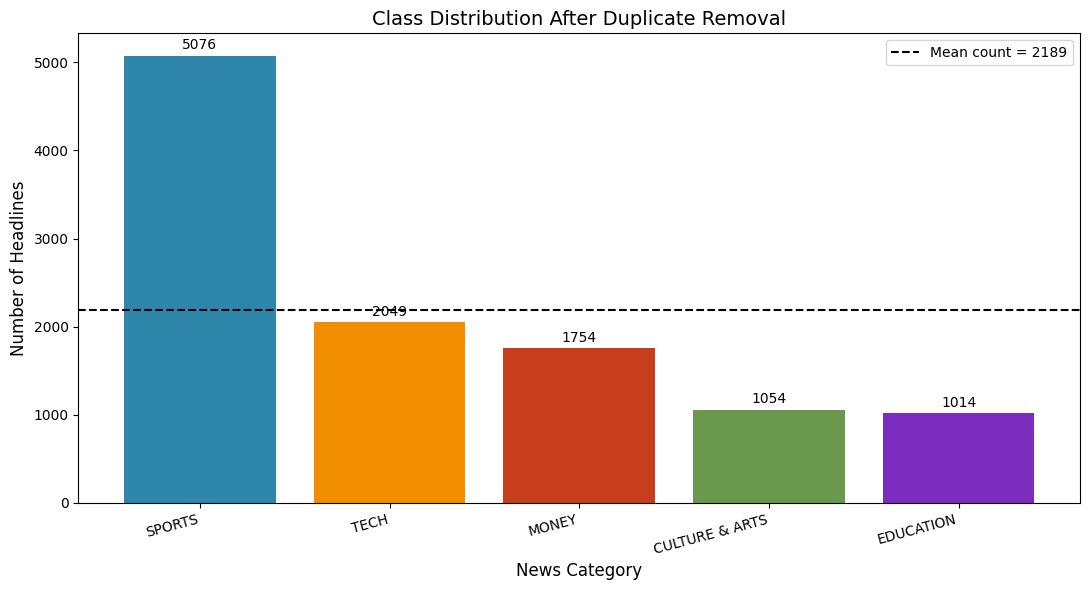

Saved figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/class_distribution.png


In [84]:
mean_class_count = class_distribution_df["count"].mean()

plt.figure(figsize=(11, 6))
bars = plt.bar(
    class_distribution_df["category"],
    class_distribution_df["count"],
    color=["#2E86AB", "#F18F01", "#C73E1D", "#6A994E", "#7B2CBF"],
)
plt.axhline(
    y=mean_class_count,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean count = {mean_class_count:.0f}",
)

for bar, count in zip(bars, class_distribution_df["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 40,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Class Distribution After Duplicate Removal", fontsize=14)
plt.xlabel("News Category", fontsize=12)
plt.ylabel("Number of Headlines", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(CLASS_DISTRIBUTION_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {CLASS_DISTRIBUTION_FIG_PATH}")


This plot visualises the class imbalance in the dataset and includes the mean class-count line for reference. The figure makes it easier to see how strongly the `SPORTS` category dominates the dataset in comparison with the smaller classes.


Headline length summary:
count    10947.00
mean         9.78
std          3.00
min          1.00
25%          8.00
50%         10.00
75%         12.00
max         28.00
Name: headline_word_count, dtype: float64
90th percentile headline length: 13.40
95th percentile headline length: 15.00
Configured MAX_LENGTH: 15


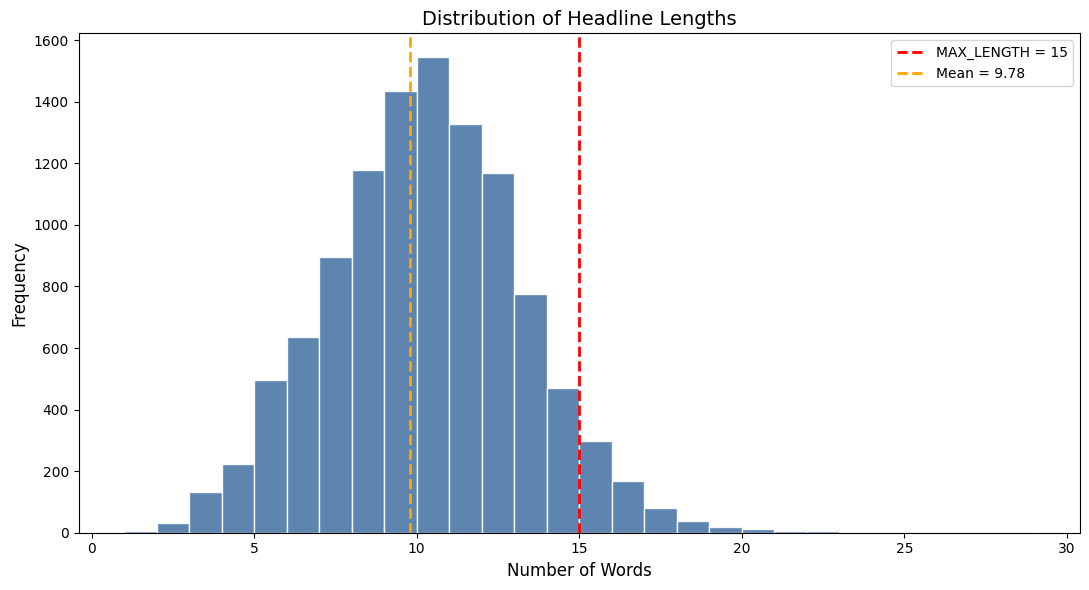

Saved figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/headline_length_distribution.png


In [85]:
df["headline_word_count"] = df[TEXT_COLUMN].astype(str).str.split().str.len()

headline_length_summary = df["headline_word_count"].describe().round(2)
length_percentile_90 = float(df["headline_word_count"].quantile(0.90))
length_percentile_95 = float(df["headline_word_count"].quantile(0.95))

print("Headline length summary:")
print(headline_length_summary)
print(f"90th percentile headline length: {length_percentile_90:.2f}")
print(f"95th percentile headline length: {length_percentile_95:.2f}")
print(f"Configured MAX_LENGTH: {MAX_LENGTH}")

plt.figure(figsize=(11, 6))
plt.hist(
    df["headline_word_count"],
    bins=range(1, int(df["headline_word_count"].max()) + 2),
    color="#4C78A8",
    edgecolor="white",
    alpha=0.9,
)
plt.axvline(
    x=MAX_LENGTH,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"MAX_LENGTH = {MAX_LENGTH}",
)
plt.axvline(
    x=df["headline_word_count"].mean(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['headline_word_count'].mean():.2f}",
)
plt.title("Distribution of Headline Lengths", fontsize=14)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(HEADLINE_LENGTH_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {HEADLINE_LENGTH_FIG_PATH}")


This cell measures headline length in words and visualises the distribution. The 95th percentile is especially important because the guide fixes `MAX_LENGTH = 15`, and the histogram helps show that this choice is well aligned with the structure of the dataset.


In [86]:
sample_headlines_per_class = (
    df.groupby(LABEL_COLUMN, group_keys=False)
    .apply(lambda group: group.sample(n=min(3, len(group)), random_state=RANDOM_STATE))
    [[LABEL_COLUMN, TEXT_COLUMN]]
    .reset_index(drop=True)
)

print("Sample headlines per class:")
display(sample_headlines_per_class)


Sample headlines per class:


/tmp/ipykernel_9693/3097689885.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min(3, len(group)), random_state=RANDOM_STATE))


,category,headline
0,CULTURE & ARTS,Stunning Vintage Photos Of Traveller's Childre...
1,CULTURE & ARTS,"The Week In Art: Alcohol, Google Street View a..."
2,CULTURE & ARTS,Joo Heng Tan's Sand Sculptures Take 24 Hours T...
3,EDUCATION,The Promise of Career and Technical Education
4,EDUCATION,'The Moment Gratitude Changed My Perspective I...
5,EDUCATION,Is PISA Data Worthless?
6,MONEY,Helping Newtown: How To Avoid Charity Hoaxes P...
7,MONEY,Target Black Friday Store Hours 2012: Store Op...
8,MONEY,Black Friday 2012 (LIVE UPDATES)
9,SPORTS,Donald Trump Is Even Taking Credit For Colin K...


This preview provides a small set of example headlines from each category. Looking at a few real samples helps show the style and vocabulary of the dataset before the cleaning pipeline is applied.


In [88]:
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df[LABEL_COLUMN])

with open(LABEL_ENCODER_PATH, "wb") as file:
    pickle.dump(le, file)

label_mapping_df = pd.DataFrame(
    {
        "encoded_label": range(len(le.classes_)),
        "category": le.classes_,
    }
)

print("Label encoding mapping:")
display(label_mapping_df)
print(f"Saved label encoder: {LABEL_ENCODER_PATH}")


Label encoding mapping:


,encoded_label,category
0,0,CULTURE & ARTS
1,1,EDUCATION
2,2,MONEY
3,3,SPORTS
4,4,TECH


Saved label encoder: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/label_encoder.pkl


This cell converts the string category labels into numeric form using `LabelEncoder`. The mapping is saved because the same label order will be needed later for model evaluation, prediction decoding, and the optional interface section.


In [91]:

X = df[TEXT_COLUMN].astype(str)
y = df["label_encoded"]

X_train_text, X_test_text, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_text = X_train_text.reset_index(drop=True)
X_test_text = X_test_text.reset_index(drop=True)
y_train_raw = y_train_raw.reset_index(drop=True)
y_test_raw = y_test_raw.reset_index(drop=True)

np.save(Y_TRAIN_RAW_PATH, y_train_raw.to_numpy())
np.save(Y_TEST_RAW_PATH, y_test_raw.to_numpy())

train_distribution = (
    pd.Series(y_train_raw).value_counts(normalize=True).sort_index().round(4)
)
test_distribution = (
    pd.Series(y_test_raw).value_counts(normalize=True).sort_index().round(4)
)

split_summary_df = pd.DataFrame(
    {
        "category": le.classes_,
        "train_proportion": train_distribution.values,
        "test_proportion": test_distribution.values,
    }
)

print("Training set size:", len(X_train_text))
print("Test set size:", len(X_test_text))
display(split_summary_df)
print(f"Saved y_train_raw array: {Y_TRAIN_RAW_PATH}")
print(f"Saved y_test_raw array: {Y_TEST_RAW_PATH}")

Training set size: 8757
Test set size: 2190


,category,train_proportion,test_proportion
0,CULTURE & ARTS,0.0963,0.0963
1,EDUCATION,0.0926,0.0927
2,MONEY,0.1602,0.1603
3,SPORTS,0.4637,0.4635
4,TECH,0.1872,0.1872


Saved y_train_raw array: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/y_train_raw.npy
Saved y_test_raw array: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/y_test_raw.npy


This cell creates the stratified 80/20 train-test split required by the guide. The class proportions in the training and test partitions are displayed so that the split can be checked for consistency with the original imbalanced dataset.


In [92]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
EMPTY_TEXT_TOKEN = "<empty>"


def clean_text(text: str) -> str:
    """Apply the required text-cleaning pipeline to a single headline."""
    if text is None:
        return EMPTY_TEXT_TOKEN

    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"@\\w+", " ", text)
    text = re.sub(r"#\\w+", " ", text)

    try:
        text = contractions.fix(text)
    except Exception:
        text = text

    text = re.sub(r"\\d+", " ", text)
    text = re.sub(r"[^a-z\\s]", " ", text)
    tokens = text.split()
    tokens = [token for token in tokens if token not in STOP_WORDS]
    tokens = [LEMMATIZER.lemmatize(token) for token in tokens]
    cleaned_text = " ".join(tokens).strip()

    return cleaned_text if cleaned_text else EMPTY_TEXT_TOKEN


example_headline = "How A New Documentary Captures The Complexity Of Being A Child Of Immigrants"
print("Original example:", example_headline)
print("Cleaned example: ", clean_text(example_headline))


Original example: How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned example:  new documentary capture complexity child immigrant


This cell defines the reusable `clean_text()` function for the project. The cleaning pipeline includes the tweet-style steps required by the guide, even though elements such as URLs, mentions, and hashtags are generally absent from news headlines. The steps that actively shape this dataset are mainly lowercasing, contraction expansion, number removal, punctuation removal, stopword removal, and lemmatization.


In [93]:
cleaning_start_time = time.time()

X_train_clean = [clean_text(text) for text in X_train_text]
X_test_clean = [clean_text(text) for text in X_test_text]

cleaning_elapsed_seconds = time.time() - cleaning_start_time
empty_train_count = sum(text == EMPTY_TEXT_TOKEN for text in X_train_clean)
empty_test_count = sum(text == EMPTY_TEXT_TOKEN for text in X_test_clean)

cleaning_preview_df = pd.DataFrame(
    {
        "original_headline": X_train_text.head(5),
        "cleaned_headline": X_train_clean[:5],
    }
)

print(f"Cleaning completed in {cleaning_elapsed_seconds:.2f} seconds.")
print("Empty cleaned headlines in training set:", empty_train_count)
print("Empty cleaned headlines in test set:", empty_test_count)
display(cleaning_preview_df)


Cleaning completed in 1.13 seconds.
Empty cleaned headlines in training set: 0
Empty cleaned headlines in test set: 0


,original_headline,cleaned_headline
0,Getting to Know Gregor Piatigorsky,getting know gregor piatigorsky
1,Didier Drogba May Move To U.S.,didier drogba may move
2,You Trying To Sign The Pipe?,trying sign pipe
3,Atlanta Falcons Player Suspended For 2022 Seas...,atlanta falcon player suspended season betting...
4,Digitally Integrated Skiing and Snowboarding: ...,digitally integrated skiing snowboarding story


This cell applies the cleaning function to the training and test headlines separately and records the processing time. The before-and-after preview helps verify that the text has been cleaned as expected, while the empty-string check confirms that the cleaned data remains safe for the later tokenization stage.


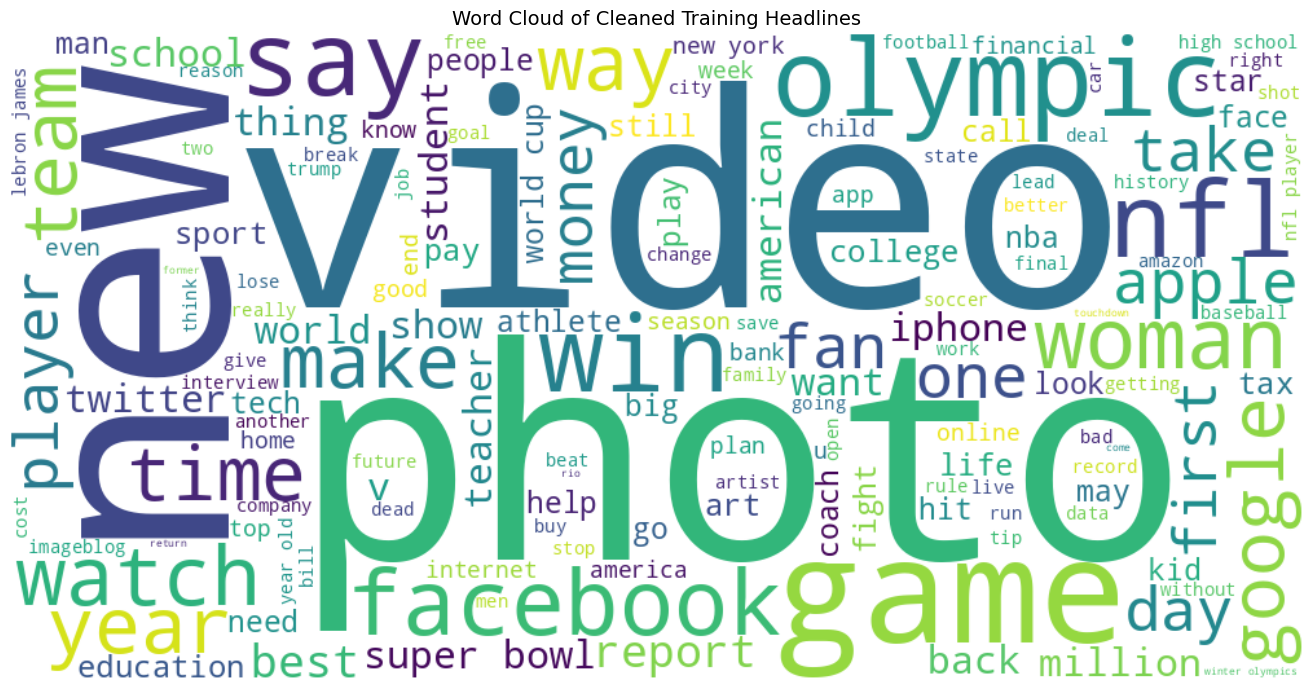

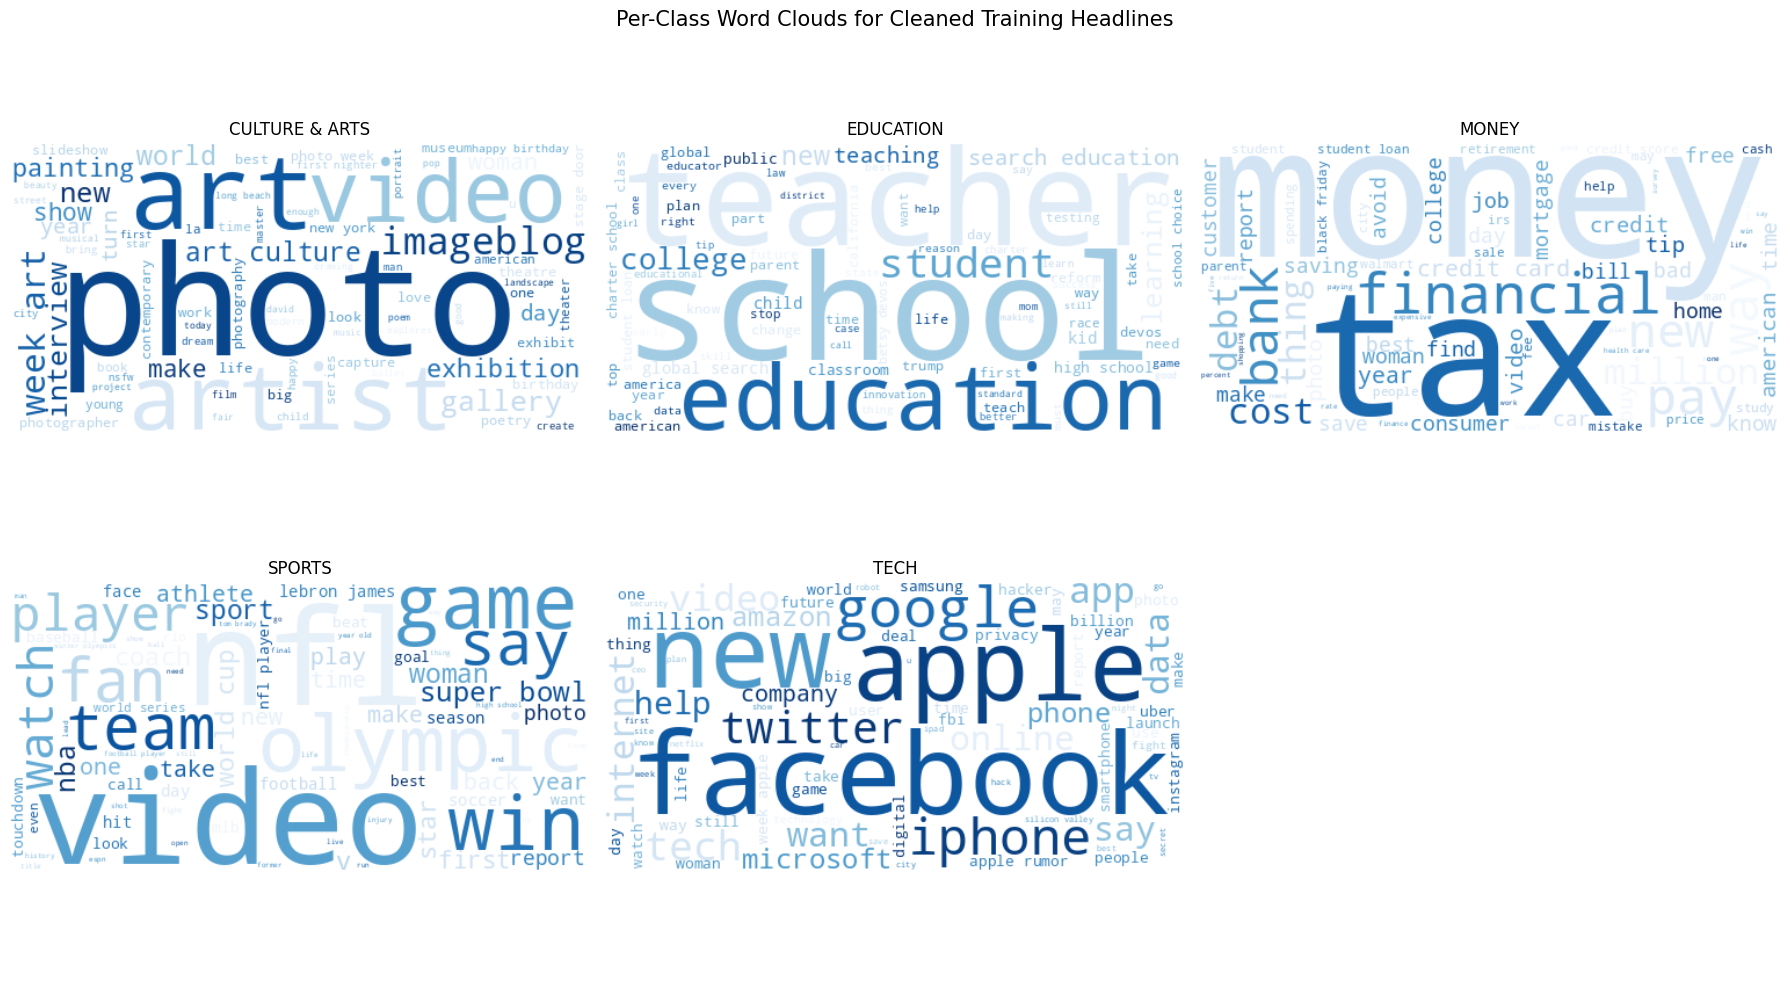

Saved figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/wordcloud_all.png
Saved figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/wordcloud_per_class.png


In [94]:
overall_training_text = " ".join(X_train_clean)

overall_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150,
    colormap="viridis",
).generate(overall_training_text)

plt.figure(figsize=(14, 7))
plt.imshow(overall_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Training Headlines", fontsize=14)
plt.tight_layout()
plt.savefig(WORDCLOUD_ALL_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

y_train_array = y_train_raw.to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for class_index, class_name in enumerate(le.classes_):
    class_text = " ".join(
        X_train_clean[idx]
        for idx in range(len(X_train_clean))
        if y_train_array[idx] == class_index
    )
    class_wordcloud = WordCloud(
        width=500,
        height=250,
        background_color="white",
        max_words=80,
        colormap="Blues",
    ).generate(class_text if class_text.strip() else EMPTY_TEXT_TOKEN)
    axes[class_index].imshow(class_wordcloud, interpolation="bilinear")
    axes[class_index].axis("off")
    axes[class_index].set_title(class_name, fontsize=12)

axes[-1].axis("off")
plt.suptitle("Per-Class Word Clouds for Cleaned Training Headlines", fontsize=15)
plt.tight_layout()
plt.savefig(WORDCLOUD_PER_CLASS_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure: {WORDCLOUD_ALL_FIG_PATH}")
print(f"Saved figure: {WORDCLOUD_PER_CLASS_FIG_PATH}")


These visualizations highlight the vocabulary that appears most strongly in the cleaned training headlines. The overall word cloud provides a broad view of the dataset, while the per-class word clouds help show which words are more characteristic of individual categories.


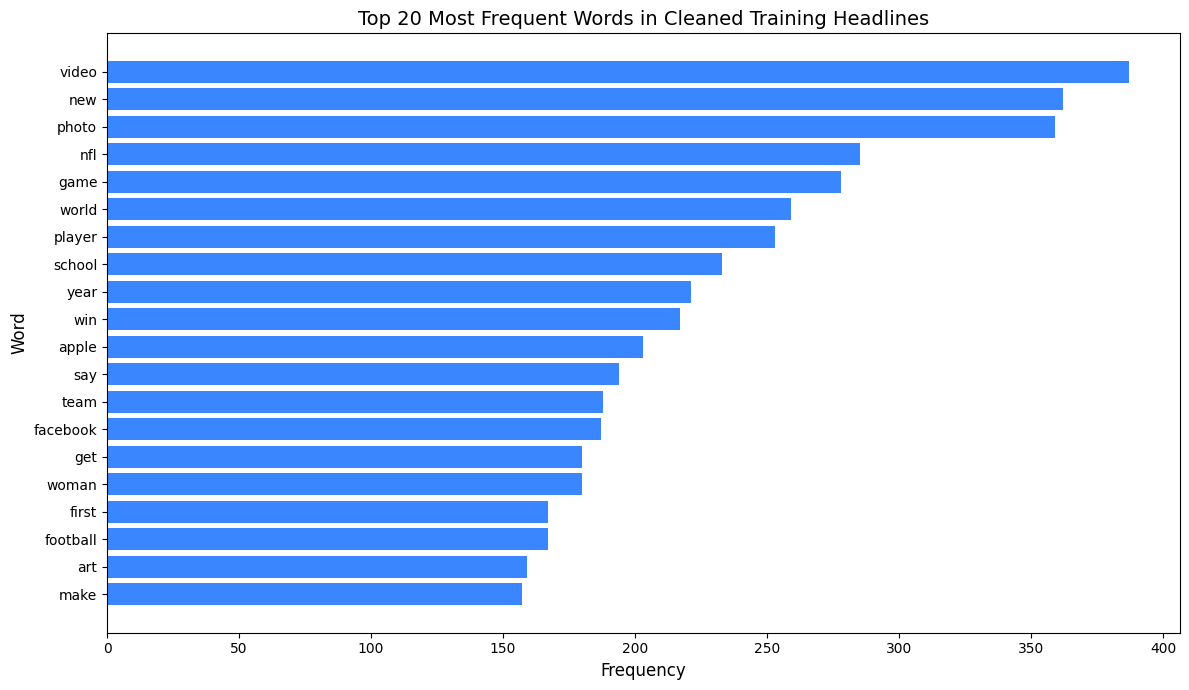

,word,frequency
0,video,387
1,new,362
2,photo,359
3,nfl,285
4,game,278
5,world,259
6,player,253
7,school,233
8,year,221
9,win,217


Saved figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/top_words_frequency.png


In [95]:
from collections import Counter

all_words = " ".join(X_train_clean).split()
top_words = Counter(all_words).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["word", "frequency"])

plt.figure(figsize=(12, 7))
plt.barh(top_words_df["word"][::-1], top_words_df["frequency"][::-1], color="#3A86FF")
plt.title("Top 20 Most Frequent Words in Cleaned Training Headlines", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Word", fontsize=12)
plt.tight_layout()
plt.savefig(TOP_WORDS_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

display(top_words_df)
print(f"Saved figure: {TOP_WORDS_FIG_PATH}")


This chart presents the most frequent tokens in the cleaned training text. It complements the word clouds by showing exact frequency counts, which is useful when discussing the dominant vocabulary patterns of the dataset.


## Tokenization and Sequence Padding

This section converts the cleaned headline text into numerical form for the recurrent models. The workflow fits a tokenizer on the training text only, handles out-of-vocabulary words safely, converts cleaned headlines into integer sequences, applies post-padding to the fixed sequence length, encodes the labels in one-hot form, and summarises the final preprocessing outputs that will be used by all three models.

In [96]:
required_names = [
    "X_train_clean",
    "X_test_clean",
    "X_train_text",
    "y_train_raw",
    "y_test_raw",
    "TOKENIZER_PATH",
    "X_TRAIN_PAD_PATH",
    "X_TEST_PAD_PATH",
    "NUM_WORDS",
    "MAX_LENGTH",
    "NUM_CLASSES",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier setup and preprocessing sections must be run first. "
        f"Missing variables or paths: {missing_names}"
    )

print("Prerequisite variables confirmed for tokenization and sequence padding.")


Prerequisite variables confirmed for tokenization and sequence padding.


This check confirms that the cleaned training and test text, encoded labels, and save paths from the earlier notebook sections are already available. The tokenization stage depends directly on those outputs.


In [97]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

vocab_size = min(NUM_WORDS, len(tokenizer.word_index) + 1)
oov_index = tokenizer.word_index.get("<OOV>")
top_token_items = list(tokenizer.word_index.items())[:10]

with open(TOKENIZER_PATH, "wb") as file:
    pickle.dump(tokenizer, file)

print("Total unique words in training vocabulary:", len(tokenizer.word_index))
print("Vocabulary size used for modelling:", vocab_size)
print("OOV token index:", oov_index)
print("\nFirst 10 tokenizer entries:")
for word, index in top_token_items:
    print(f"  {word!r}: {index}")

print(f"\nSaved tokenizer: {TOKENIZER_PATH}")


Total unique words in training vocabulary: 11352
Vocabulary size used for modelling: 10000
OOV token index: 1

First 10 tokenizer entries:
  '<OOV>': 1
  'video': 2
  'new': 3
  'photo': 4
  'nfl': 5
  'game': 6
  'world': 7
  'player': 8
  'school': 9
  'year': 10

Saved tokenizer: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/tokenizer.pkl


This cell creates the tokenizer and fits it only on the cleaned training text, which avoids data leakage from the test set. The `<OOV>` token is included so that unseen words in later evaluation or prediction are mapped safely rather than being confused with the padding index.


In [98]:
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

train_sequence_lengths = np.array([len(sequence) for sequence in X_train_seq], dtype=int)
test_sequence_lengths = np.array([len(sequence) for sequence in X_test_seq], dtype=int)

sequence_length_summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "mean_length": [
            float(train_sequence_lengths.mean()),
            float(test_sequence_lengths.mean()),
        ],
        "median_length": [
            float(np.median(train_sequence_lengths)),
            float(np.median(test_sequence_lengths)),
        ],
        "max_length": [
            int(train_sequence_lengths.max()),
            int(test_sequence_lengths.max()),
        ],
        "95th_percentile": [
            float(np.quantile(train_sequence_lengths, 0.95)),
            float(np.quantile(test_sequence_lengths, 0.95)),
        ],
    }
)

print("Example original headline:")
print(X_train_text.iloc[0])
print("\nExample cleaned headline:")
print(X_train_clean[0])
print("\nExample integer sequence:")
print(X_train_seq[0])
print("Example sequence length:", len(X_train_seq[0]))
print("\nSequence length summary:")
display(sequence_length_summary_df.round(2))


Example original headline:
Getting to Know Gregor Piatigorsky

Example cleaned headline:
getting know gregor piatigorsky

Example integer sequence:
[184, 65, 5629, 5630]
Example sequence length: 4

Sequence length summary:


,split,mean_length,median_length,max_length,95th_percentile
0,train,6.97,7.0,19,11.0
1,test,6.89,7.0,16,11.0


This cell converts the cleaned headlines into integer sequences and gives a concrete example of how a single headline is transformed. The summary table also shows the tokenized sequence lengths, which helps confirm that the fixed padding length of `15` remains appropriate after tokenization.


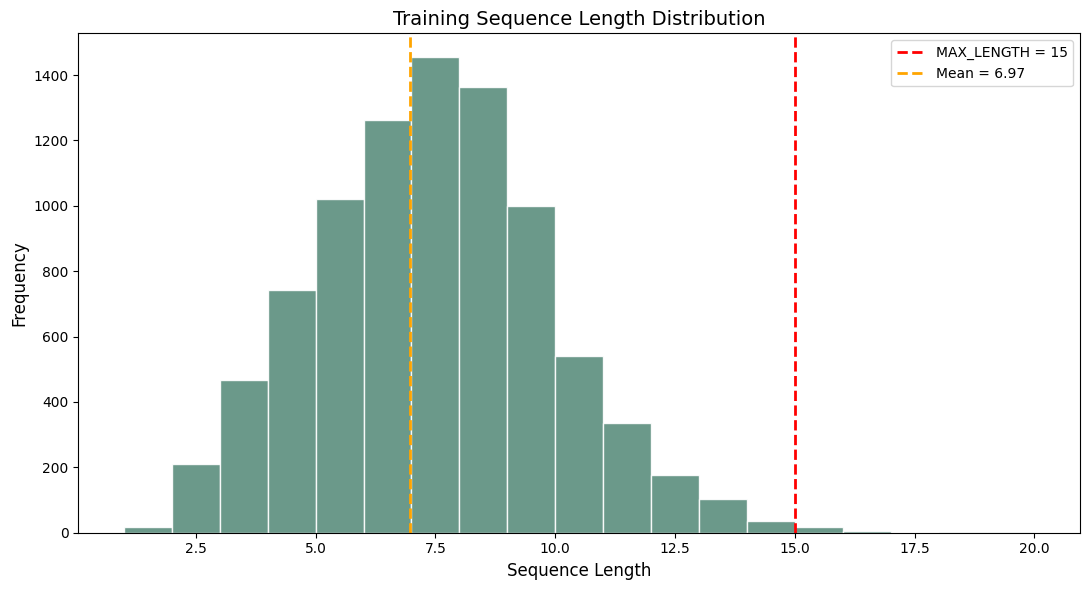

In [99]:
plt.figure(figsize=(11, 6))
plt.hist(
    train_sequence_lengths,
    bins=range(1, int(train_sequence_lengths.max()) + 2),
    color="#5B8E7D",
    edgecolor="white",
    alpha=0.9,
)
plt.axvline(
    x=MAX_LENGTH,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"MAX_LENGTH = {MAX_LENGTH}",
)
plt.axvline(
    x=float(train_sequence_lengths.mean()),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {train_sequence_lengths.mean():.2f}",
)
plt.title("Training Sequence Length Distribution", fontsize=14)
plt.xlabel("Sequence Length", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


This histogram shows the distribution of tokenized training-sequence lengths with the selected `MAX_LENGTH` marker. It provides a direct sequence-level justification for the chosen padding limit and helps show that the selected length does not introduce excessive truncation for this short-headline dataset.


In [100]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post",
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post",
)

np.save(X_TRAIN_PAD_PATH, X_train_pad)
np.save(X_TEST_PAD_PATH, X_test_pad)

print("Padded training shape:", X_train_pad.shape)
print("Padded test shape:", X_test_pad.shape)
print("\nExample padded training sequence:")
print(X_train_pad[0])
print(f"\nSaved padded training array: {X_TRAIN_PAD_PATH}")
print(f"Saved padded test array: {X_TEST_PAD_PATH}")


Padded training shape: (8757, 15)
Padded test shape: (2190, 15)

Example padded training sequence:
[ 184   65 5629 5630    0    0    0    0    0    0    0    0    0    0
    0]

Saved padded training array: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/X_train_pad.npy
Saved padded test array: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/X_test_pad.npy


This cell applies post-padding and post-truncation to the fixed sequence length of `15`. The padded arrays are saved immediately because they will be reused across all three models and should remain available even if the Colab session is interrupted later.


In [101]:
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test_raw, num_classes=NUM_CLASSES)

print("One-hot encoded training label shape:", y_train.shape)
print("One-hot encoded test label shape:", y_test.shape)
print("\nExample encoded labels:")
print("Raw label:", int(y_train_raw.iloc[0]))
print("One-hot vector:", y_train[0])


One-hot encoded training label shape: (8757, 5)
One-hot encoded test label shape: (2190, 5)

Example encoded labels:
Raw label: 0
One-hot vector: [1. 0. 0. 0. 0.]


This cell converts the integer class labels into one-hot vectors for categorical cross-entropy. Since the task has five categories, one-hot encoding is the correct label format for the softmax models used later in the notebook.


In [102]:
preprocessing_summary_df = pd.DataFrame(
    {
        "component": [
            "Training samples",
            "Test samples",
            "Tokenizer fit scope",
            "Vocabulary cap",
            "Observed vocabulary size",
            "OOV token",
            "Padding length",
            "Padding mode",
            "Truncation mode",
            "Training tensor shape",
            "Test tensor shape",
            "Label encoding",
            "Number of classes",
        ],
        "value": [
            len(X_train_pad),
            len(X_test_pad),
            "Training text only",
            NUM_WORDS,
            vocab_size,
            "<OOV>",
            MAX_LENGTH,
            "post",
            "post",
            X_train_pad.shape,
            X_test_pad.shape,
            "to_categorical",
            NUM_CLASSES,
        ],
    }
)

display(preprocessing_summary_df)


,component,value
0,Training samples,8757
1,Test samples,2190
2,Tokenizer fit scope,Training text only
3,Vocabulary cap,10000
4,Observed vocabulary size,10000
5,OOV token,<OOV>
6,Padding length,15
7,Padding mode,post
8,Truncation mode,post
9,Training tensor shape,"(8757, 15)"


This summary table consolidates the main outputs of the tokenization and padding stage. It provides a compact reference for the vocabulary, sequence length, tensor shapes, and label representation that will be used in the modelling sections.


## Simple RNN with Trainable Embedding

This section introduces the first recurrent baseline model for the news category classification task. The model uses a trainable embedding layer followed by a SimpleRNN layer, a dropout layer, and a five-class softmax output. Its purpose is to establish a clear baseline against which the later LSTM-based models can be compared.

In [103]:
required_names = [
    "X_train_pad",
    "X_test_pad",
    "y_train",
    "y_test",
    "y_test_raw",
    "NUM_CLASSES",
    "EMBEDDING_DIM",
    "RNN_UNITS",
    "MAX_LENGTH",
    "BATCH_SIZE",
    "EPOCHS",
    "vocab_size",
    "le",
    "MODEL1_CHECKPOINT_PATH",
    "HISTORY_RNN_PATH",
    "MODEL1_REPORT_PATH",
    "MODEL1_LOSS_FIG_PATH",
    "MODEL1_ACCURACY_FIG_PATH",
    "MODEL1_CONFUSION_FIG_PATH",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier preprocessing sections must be run first. "
        f"Missing variables or paths: {missing_names}"
    )

print("Prerequisite variables confirmed for the Simple RNN section.")


Prerequisite variables confirmed for the Simple RNN section.


This check confirms that the padded headline sequences, one-hot labels, vocabulary size, and required save paths are already available. The baseline recurrent model depends directly on these outputs from the earlier preprocessing stages.


The SimpleRNN model is used here as the first recurrent baseline because it provides a straightforward sequence-learning architecture with relatively low complexity. The embedding layer begins with random trainable vectors, so the model must learn both useful word representations and a sequence classifier from the training data. This makes the model suitable as a reference point for later comparisons with LSTM-based alternatives.


In [104]:
def save_history_to_json(history, output_path: Path) -> None:
    serializable_history = {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }
    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(serializable_history, file, indent=2)


def save_classification_report_text(report_text: str, output_path: Path) -> None:
    with open(output_path, "w", encoding="utf-8") as file:
        file.write(report_text)


def clear_tensorflow_memory() -> None:
    gc.collect()
    tf.keras.backend.clear_session()


def create_standard_callbacks(checkpoint_path: Path) -> list:
    return [
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]


def plot_training_history_with_references(
    history,
    loss_output_path: Path,
    accuracy_output_path: Path,
    random_chance: float = 0.20,
    majority_baseline: float = 0.464,
) -> None:
    epochs = range(1, len(history.history["loss"]) + 1)
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    plt.figure(figsize=(11, 5))
    plt.plot(epochs, history.history["loss"], label="Training loss", linewidth=2)
    plt.plot(epochs, history.history["val_loss"], label="Validation loss", linewidth=2)
    plt.axvline(best_epoch, color="black", linestyle="--", linewidth=1.5, label=f"Best epoch = {best_epoch}")
    plt.title("Simple RNN Training and Validation Loss", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_output_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(epochs, history.history["accuracy"], label="Training accuracy", linewidth=2)
    plt.plot(epochs, history.history["val_accuracy"], label="Validation accuracy", linewidth=2)
    plt.axvline(best_epoch, color="black", linestyle="--", linewidth=1.5, label=f"Best epoch = {best_epoch}")
    plt.axhline(random_chance, color="red", linestyle="--", linewidth=1.5, label=f"Random chance = {random_chance:.2f}")
    plt.axhline(majority_baseline, color="purple", linestyle="--", linewidth=1.5, label=f"Majority baseline = {majority_baseline:.3f}")
    plt.title("Simple RNN Training and Validation Accuracy", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(accuracy_output_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix_heatmap(y_true, y_pred, class_names, output_path: Path) -> None:
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title("Simple RNN Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


These helper functions support the baseline recurrent-model workflow by handling history export, report export, callback creation, memory cleanup, training-curve plotting, and confusion-matrix visualization. Keeping them together here makes the later model sections easier to reuse and compare.


In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

These metric imports are declared explicitly in the model section so that the evaluation cells do not depend on earlier notebook state beyond the preprocessing outputs. This keeps the section easier to rerun independently if needed.

In [105]:
def build_simple_rnn_model(
    input_dim: int,
    embedding_dim: int,
    input_length: int,
    num_classes: int,
    rnn_units: int,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Embedding(
                input_dim=input_dim,
                output_dim=embedding_dim,
                input_length=input_length,
                trainable=True,
                name="embedding_layer",
            ),
            tf.keras.layers.SimpleRNN(rnn_units, name="simple_rnn_layer"),
            tf.keras.layers.Dropout(0.3, name="dropout_layer"),
            tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer"),
        ],
        name="simple_rnn_classifier",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


This function defines the baseline recurrent architecture exactly as required for Model 1. The embedding layer is trainable, the recurrent layer uses `64` SimpleRNN units, dropout is set to `0.3`, and the output layer uses `5` softmax units for the five news categories.


In [106]:
clear_tensorflow_memory()

model_rnn = build_simple_rnn_model(
    input_dim=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    input_length=MAX_LENGTH,
    num_classes=NUM_CLASSES,
    rnn_units=RNN_UNITS,
)

model_rnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_layer (SimpleRNN)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The model summary shows how the padded integer sequences are first mapped into dense trainable word vectors and then processed by the SimpleRNN layer. In this architecture, the embedding layer contributes a large share of the parameters because every vocabulary index receives a learned vector representation, while the recurrent and output layers perform the sequence modelling and final classification.


In [107]:
simple_rnn_callbacks = create_standard_callbacks(MODEL1_CHECKPOINT_PATH)

simple_rnn_training_start = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=simple_rnn_callbacks,
    verbose=1,
)

simple_rnn_training_seconds = time.time() - simple_rnn_training_start

save_history_to_json(history_rnn, HISTORY_RNN_PATH)

print(f"Training time (seconds): {simple_rnn_training_seconds:.2f}")
print(f"Saved history: {HISTORY_RNN_PATH}")


Epoch 1/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5318 - loss: 1.2076
Epoch 1: val_loss improved from None to 0.61180, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model1_rnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model1_rnn_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6482 - loss: 0.9576 - val_accuracy: 0.7936 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 2/50
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8493 - loss: 0.4582
Epoch 2: val_loss improved from 0.61180 to 0.55915, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model1_rnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model1_rnn_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8841 - loss: 0.3590 - val_accuracy: 0.8224 - val_loss: 0.5591 - learning_rate: 0.0010
Epoch 3/50
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accura

This cell trains the SimpleRNN model using the padded training data and the held-out validation split. Early stopping, checkpointing, and learning-rate reduction are all enabled so that the model can stop at a sensible point while preserving the best-performing weights.


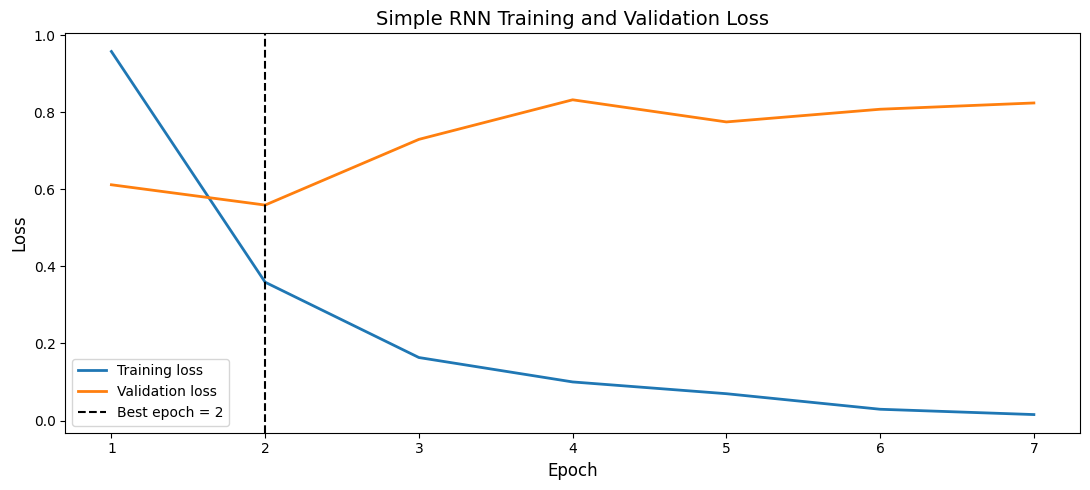

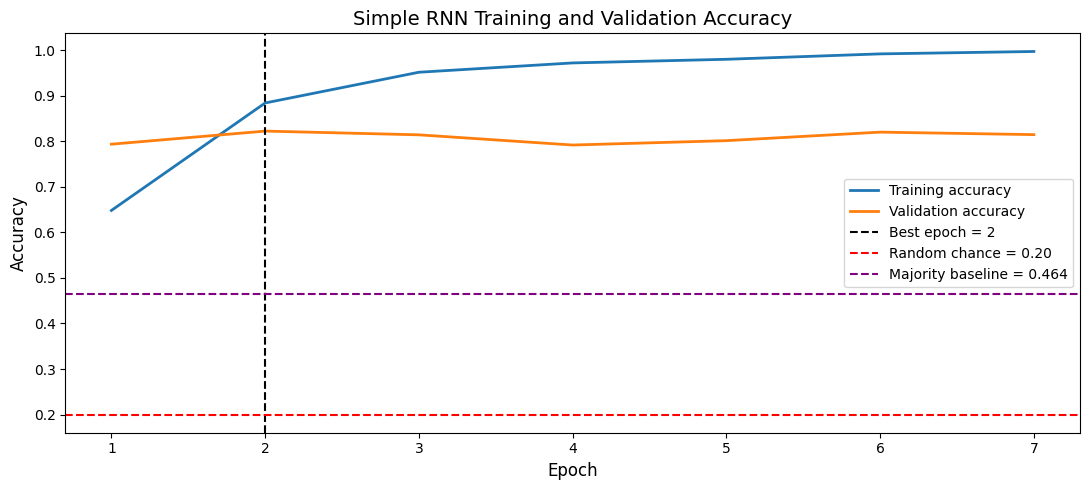

Saved loss figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model1_rnn_loss_curve.png
Saved accuracy figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model1_rnn_accuracy_curve.png


In [108]:
plot_training_history_with_references(
    history=history_rnn,
    loss_output_path=MODEL1_LOSS_FIG_PATH,
    accuracy_output_path=MODEL1_ACCURACY_FIG_PATH,
)

print(f"Saved loss figure: {MODEL1_LOSS_FIG_PATH}")
print(f"Saved accuracy figure: {MODEL1_ACCURACY_FIG_PATH}")


These plots show how the baseline model learns across epochs. The validation-accuracy plot also includes both the random-chance line (`0.20`) and the majority-class baseline (`0.464`), which is especially important for this imbalanced five-class dataset.


In [111]:
model_rnn = tf.keras.models.load_model(MODEL1_CHECKPOINT_PATH)

y_prob_rnn = model_rnn.predict(X_test_pad, verbose=0)
y_pred_rnn = np.argmax(y_prob_rnn, axis=1)
y_true_rnn = y_test_raw.to_numpy()

test_accuracy_rnn = accuracy_score(y_true_rnn, y_pred_rnn)
report_text_rnn = classification_report(
    y_true_rnn,
    y_pred_rnn,
    target_names=le.classes_,
    digits=4,
)
report_dict_rnn = classification_report(
    y_true_rnn,
    y_pred_rnn,
    target_names=le.classes_,
    output_dict=True,
)

macro_precision_rnn = float(report_dict_rnn["macro avg"]["precision"])
macro_recall_rnn = float(report_dict_rnn["macro avg"]["recall"])
macro_f1_rnn = float(report_dict_rnn["macro avg"]["f1-score"])
weighted_f1_rnn = float(report_dict_rnn["weighted avg"]["f1-score"])

save_classification_report_text(report_text_rnn, MODEL1_REPORT_PATH)

print(f"Validation accuracy: {test_accuracy_rnn:.4f}")
print(f"Macro precision: {macro_precision_rnn:.4f}")
print(f"Macro recall: {macro_recall_rnn:.4f}")
print(f"Macro F1-score: {macro_f1_rnn:.4f}")
print(f"Weighted F1-score: {weighted_f1_rnn:.4f}")
print("\nClassification report:")
print(report_text_rnn)
print(f"Saved report: {MODEL1_REPORT_PATH}")


Validation accuracy: 0.8224
Macro precision: 0.7836
Macro recall: 0.7471
Macro F1-score: 0.7580
Weighted F1-score: 0.8201

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS     0.6314    0.7062    0.6667       211
     EDUCATION     0.8615    0.5517    0.6727       203
         MONEY     0.7151    0.7436    0.7291       351
        SPORTS     0.9033    0.9389    0.9208      1015
          TECH     0.8069    0.7951    0.8010       410

      accuracy                         0.8224      2190
     macro avg     0.7836    0.7471    0.7580      2190
  weighted avg     0.8250    0.8224    0.8201      2190

Saved report: /content/drive/MyDrive/News-dataset/news_category_outputs/metrics/model1_rnn_classification_report.txt


This evaluation cell reloads the best saved baseline model, generates predictions on the held-out data, and reports the main classification metrics. Because the dataset is imbalanced, macro F1-score and weighted F1-score are reported alongside accuracy rather than relying on accuracy alone.


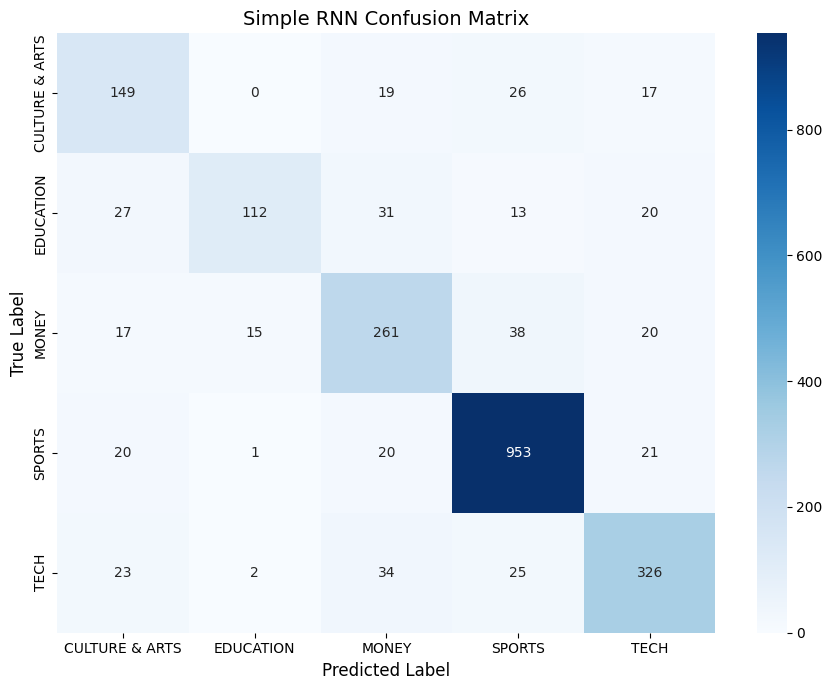

Saved confusion matrix figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model1_rnn_confusion_matrix.png


In [112]:
plot_confusion_matrix_heatmap(
    y_true=y_true_rnn,
    y_pred=y_pred_rnn,
    class_names=le.classes_,
    output_path=MODEL1_CONFUSION_FIG_PATH,
)

print(f"Saved confusion matrix figure: {MODEL1_CONFUSION_FIG_PATH}")


The confusion matrix provides a class-by-class view of the baseline model’s performance. It helps show which news categories are separated more clearly and which categories are more easily confused at this stage of the modelling pipeline.


In [113]:
best_epoch_rnn = int(np.argmin(history_rnn.history["val_loss"])) + 1

simple_rnn_results = {
    "model_name": "Simple RNN with Trainable Embedding",
    "checkpoint_path": str(MODEL1_CHECKPOINT_PATH),
    "history_path": str(HISTORY_RNN_PATH),
    "classification_report_path": str(MODEL1_REPORT_PATH),
    "loss_figure_path": str(MODEL1_LOSS_FIG_PATH),
    "accuracy_figure_path": str(MODEL1_ACCURACY_FIG_PATH),
    "confusion_matrix_figure_path": str(MODEL1_CONFUSION_FIG_PATH),
    "training_time_seconds": float(simple_rnn_training_seconds),
    "training_time_minutes": float(simple_rnn_training_seconds / 60.0),
    "actual_epochs_trained": int(len(history_rnn.history["loss"])),
    "best_epoch": best_epoch_rnn,
    "best_val_loss": float(np.min(history_rnn.history["val_loss"])),
    "best_val_accuracy": float(np.max(history_rnn.history["val_accuracy"])),
    "test_accuracy": float(test_accuracy_rnn),
    "macro_precision": macro_precision_rnn,
    "macro_recall": macro_recall_rnn,
    "macro_f1": macro_f1_rnn,
    "weighted_f1": weighted_f1_rnn,
    "trainable_parameters": int(np.sum([np.prod(w.shape) for w in model_rnn.trainable_weights])),
    "non_trainable_parameters": int(np.sum([np.prod(w.shape) for w in model_rnn.non_trainable_weights])),
    "embedding_dim": int(EMBEDDING_DIM),
    "sequence_length": int(MAX_LENGTH),
    "batch_size": int(BATCH_SIZE),
    "epoch_limit": int(EPOCHS),
    "gpu_used": get_gpu_name(),
}

display(pd.DataFrame([simple_rnn_results]))


,model_name,checkpoint_path,history_path,classification_report_path,loss_figure_path,accuracy_figure_path,confusion_matrix_figure_path,training_time_seconds,training_time_minutes,actual_epochs_trained,...,macro_recall,macro_f1,weighted_f1,trainable_parameters,non_trainable_parameters,embedding_dim,sequence_length,batch_size,epoch_limit,gpu_used
0,Simple RNN with Trainable Embedding,/content/drive/MyDrive/News-dataset/checkpoint...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,26.39328,0.439888,7,...,0.747103,0.758029,0.820139,648581,0,64,15,32,50,Tesla T4


This summary table consolidates the main baseline-model results in a structured form. Keeping the result values together in one place makes later comparisons with the LSTM and GloVe-based models much easier to manage.


The baseline SimpleRNN provides an initial recurrent benchmark for the task, but its sequence-learning capacity is limited compared with gated recurrent architectures. The next section therefore explores whether replacing the SimpleRNN layer with an LSTM layer improves validation performance, class-level balance, and overall generalisation.


## LSTM with Trainable Embedding

This section replaces the SimpleRNN layer with an LSTM layer while keeping the remaining model settings unchanged. The purpose of this model is to examine whether the gated recurrent structure of LSTM improves sequence learning, class-wise balance, and overall validation performance on the news category classification task.

In [114]:
required_names = [
    "X_train_pad",
    "X_test_pad",
    "y_train",
    "y_test",
    "y_test_raw",
    "NUM_CLASSES",
    "EMBEDDING_DIM",
    "LSTM_UNITS",
    "MAX_LENGTH",
    "BATCH_SIZE",
    "EPOCHS",
    "vocab_size",
    "le",
    "MODEL2_CHECKPOINT_PATH",
    "HISTORY_LSTM_PATH",
    "MODEL2_REPORT_PATH",
    "MODEL2_LOSS_FIG_PATH",
    "MODEL2_ACCURACY_FIG_PATH",
    "MODEL2_CONFUSION_FIG_PATH",
    "RNN_VS_LSTM_LOSS_FIG_PATH",
    "RNN_VS_LSTM_ACCURACY_FIG_PATH",
    "MODEL_COMPARISON_TABLE_PATH",
    "history_rnn",
    "simple_rnn_results",
    "save_history_to_json",
    "save_classification_report_text",
    "clear_tensorflow_memory",
    "create_standard_callbacks",
    "plot_training_history_with_references",
    "plot_confusion_matrix_heatmap",
    "get_gpu_name",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier preprocessing and Simple RNN sections must be run first. "
        f"Missing variables, paths, or helper functions: {missing_names}"
    )

print("Prerequisite variables confirmed for the LSTM section.")


Prerequisite variables confirmed for the LSTM section.


This check confirms that the padded inputs, one-hot labels, save paths, helper functions, and the earlier SimpleRNN results are already available. The LSTM section depends on the same preprocessed data and also needs the baseline outputs for direct comparison.


An LSTM layer extends the basic recurrent approach by introducing a memory cell together with input, forget, and output gates. These gates help control what information should be retained or discarded across time steps, which makes LSTM generally more stable than SimpleRNN when sequence dependencies become more difficult to model. In this notebook, the LSTM model keeps the same embedding dimension, dropout rate, optimizer, batch size, and epoch limit as the baseline model so that the comparison remains fair.


In [115]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def plot_rnn_vs_lstm_overlays(
    rnn_history,
    lstm_history,
    loss_output_path: Path,
    accuracy_output_path: Path,
    random_chance: float = 0.20,
    majority_baseline: float = 0.464,
) -> None:
    rnn_epochs = range(1, len(rnn_history.history["loss"]) + 1)
    lstm_epochs = range(1, len(lstm_history.history["loss"]) + 1)

    plt.figure(figsize=(11, 5))
    plt.plot(rnn_epochs, rnn_history.history["loss"], label="SimpleRNN training loss", linewidth=2)
    plt.plot(rnn_epochs, rnn_history.history["val_loss"], label="SimpleRNN validation loss", linewidth=2)
    plt.plot(lstm_epochs, lstm_history.history["loss"], label="LSTM training loss", linewidth=2)
    plt.plot(lstm_epochs, lstm_history.history["val_loss"], label="LSTM validation loss", linewidth=2)
    plt.title("SimpleRNN and LSTM Loss Comparison", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_output_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(rnn_epochs, rnn_history.history["accuracy"], label="SimpleRNN training accuracy", linewidth=2)
    plt.plot(rnn_epochs, rnn_history.history["val_accuracy"], label="SimpleRNN validation accuracy", linewidth=2)
    plt.plot(lstm_epochs, lstm_history.history["accuracy"], label="LSTM training accuracy", linewidth=2)
    plt.plot(lstm_epochs, lstm_history.history["val_accuracy"], label="LSTM validation accuracy", linewidth=2)
    plt.axhline(random_chance, color="red", linestyle="--", linewidth=1.5, label=f"Random chance = {random_chance:.2f}")
    plt.axhline(majority_baseline, color="purple", linestyle="--", linewidth=1.5, label=f"Majority baseline = {majority_baseline:.3f}")
    plt.title("SimpleRNN and LSTM Accuracy Comparison", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(accuracy_output_path, dpi=150, bbox_inches="tight")
    plt.show()


This cell imports the evaluation metrics again for local independence and defines the overlay-plot helper used for direct comparison between the two recurrent models. The overlay figures are important because they show whether the LSTM changes both convergence behaviour and validation performance relative to the SimpleRNN baseline.


In [116]:
def build_lstm_model(
    input_dim: int,
    embedding_dim: int,
    input_length: int,
    num_classes: int,
    lstm_units: int,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Embedding(
                input_dim=input_dim,
                output_dim=embedding_dim,
                input_length=input_length,
                trainable=True,
                name="embedding_layer",
            ),
            tf.keras.layers.LSTM(lstm_units, name="lstm_layer"),
            tf.keras.layers.Dropout(0.3, name="dropout_layer"),
            tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer"),
        ],
        name="lstm_classifier",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


This function defines the second model exactly as required for the LSTM experiment. The only architectural change relative to Model 1 is the recurrent layer itself: `SimpleRNN(64)` is replaced with `LSTM(64)`, while the embedding dimension, dropout rate, softmax output, optimizer, and loss function remain unchanged.


In [117]:
clear_tensorflow_memory()

model_lstm = build_lstm_model(
    input_dim=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    input_length=MAX_LENGTH,
    num_classes=NUM_CLASSES,
    lstm_units=LSTM_UNITS,
)

model_lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The LSTM summary should show a larger recurrent parameter count than the SimpleRNN baseline because an LSTM maintains multiple gated transformations rather than a single recurrent transformation. The embedding layer still contributes a large number of parameters because the vocabulary-level word vectors are trainable, but the main architectural difference appears in the recurrent layer itself.


In [118]:
model_rnn_trainable_params = int(
    np.sum([np.prod(weight.shape) for weight in model_rnn.trainable_weights])
)
model_lstm_trainable_params = int(
    np.sum([np.prod(weight.shape) for weight in model_lstm.trainable_weights])
)

parameter_comparison_df = pd.DataFrame(
    [
        {
            "model": "Simple RNN",
            "trainable_parameters": model_rnn_trainable_params,
            "non_trainable_parameters": int(
                np.sum([np.prod(weight.shape) for weight in model_rnn.non_trainable_weights])
            ),
        },
        {
            "model": "LSTM",
            "trainable_parameters": model_lstm_trainable_params,
            "non_trainable_parameters": int(
                np.sum([np.prod(weight.shape) for weight in model_lstm.non_trainable_weights])
            ),
        },
    ]
)

display(parameter_comparison_df)


,model,trainable_parameters,non_trainable_parameters
0,Simple RNN,648581,0
1,LSTM,0,0


This small comparison highlights the parameter increase introduced by the LSTM layer. Since both models use the same vocabulary size, embedding dimension, sequence length, and output layer, the main change in complexity comes from the gated recurrent unit.


In [119]:
lstm_callbacks = create_standard_callbacks(MODEL2_CHECKPOINT_PATH)

lstm_training_start = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=lstm_callbacks,
    verbose=1,
)

lstm_training_seconds = time.time() - lstm_training_start

save_history_to_json(history_lstm, HISTORY_LSTM_PATH)

print(f"Training time (seconds): {lstm_training_seconds:.2f}")
print(f"Saved history: {HISTORY_LSTM_PATH}")


Epoch 1/50
266/274 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4880 - loss: 1.3113
Epoch 1: val_loss improved from None to 0.81782, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model2_lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model2_lstm_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.5519 - loss: 1.0879 - val_accuracy: 0.6333 - val_loss: 0.8178 - learning_rate: 0.0010
Epoch 2/50
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6797 - loss: 0.7481
Epoch 2: val_loss improved from 0.81782 to 0.63699, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model2_lstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model2_lstm_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7340 - loss: 0.6422 - val_accuracy: 0.7753 - val_loss: 0.6370 - learning_rate: 0.0010
Epoch 3/50
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

This cell trains the LSTM model using exactly the same training and validation tensors used by the baseline model. With identical optimizer settings and callbacks, the resulting performance difference can be interpreted mainly as the effect of replacing the recurrent layer.


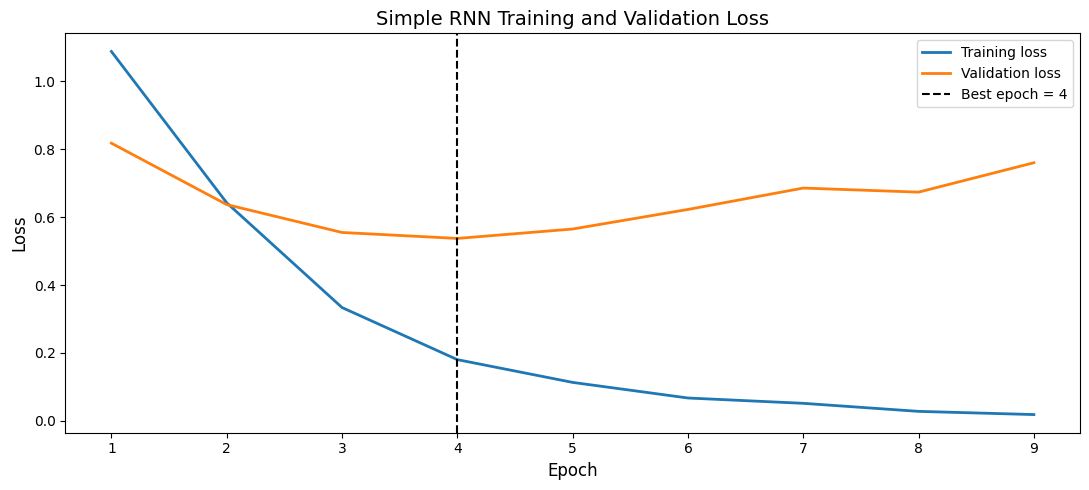

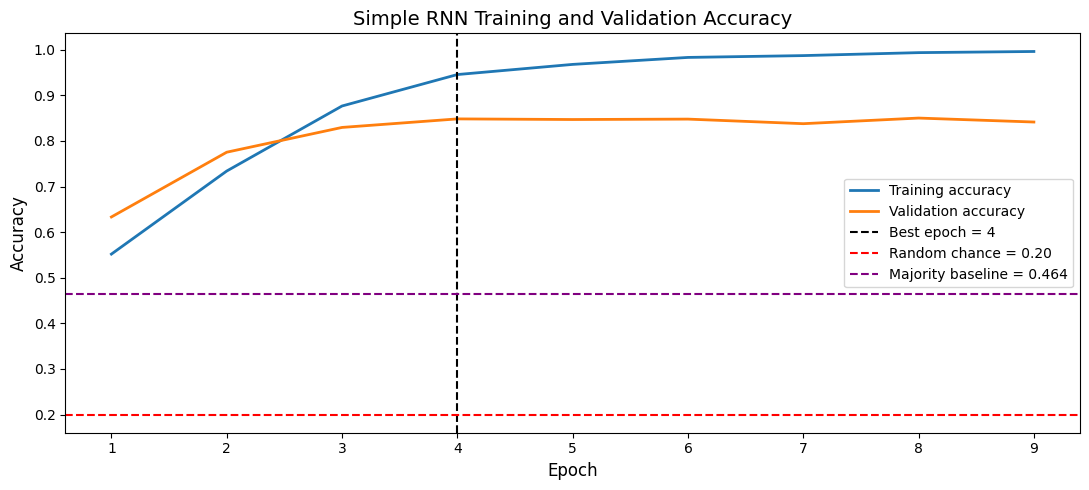

Saved loss figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model2_lstm_loss_curve.png
Saved accuracy figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model2_lstm_accuracy_curve.png


In [120]:
plot_training_history_with_references(
    history=history_lstm,
    loss_output_path=MODEL2_LOSS_FIG_PATH,
    accuracy_output_path=MODEL2_ACCURACY_FIG_PATH,
)

print(f"Saved loss figure: {MODEL2_LOSS_FIG_PATH}")
print(f"Saved accuracy figure: {MODEL2_ACCURACY_FIG_PATH}")


These figures show the individual learning behaviour of the LSTM model. As with the baseline model, the accuracy plot includes the random-chance and majority-class reference lines so that the validation performance can be interpreted against meaningful baselines for this imbalanced dataset.


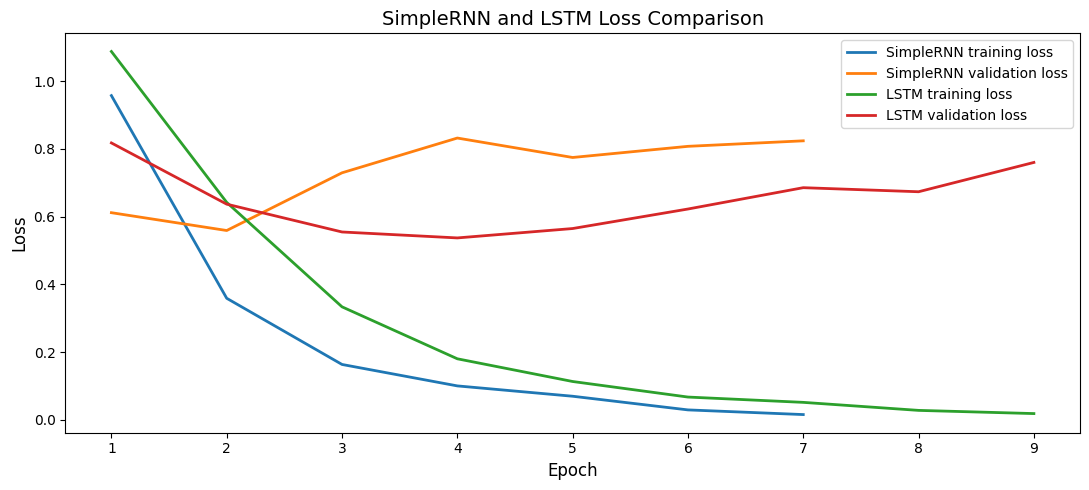

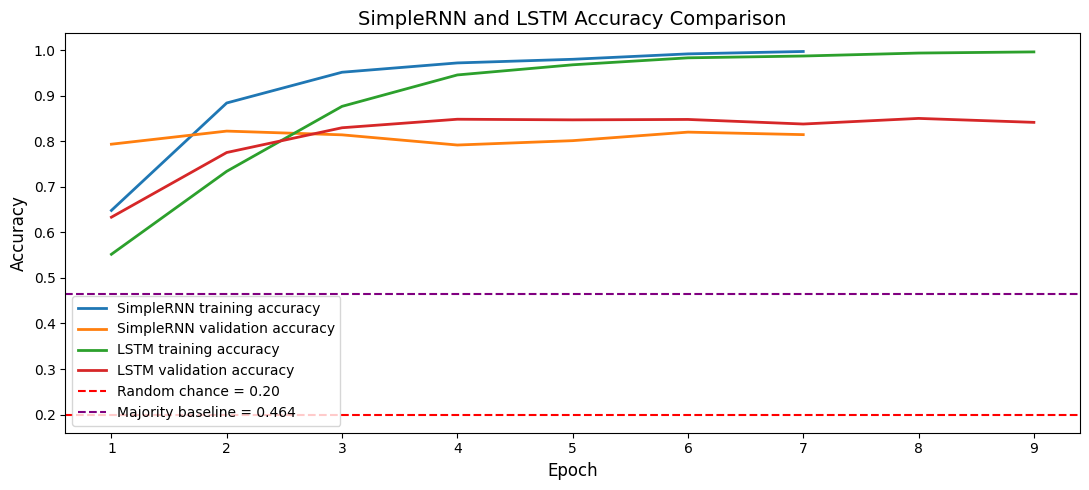

Saved overlay loss figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/rnn_vs_lstm_loss_overlay.png
Saved overlay accuracy figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/rnn_vs_lstm_accuracy_overlay.png


In [121]:
plot_rnn_vs_lstm_overlays(
    rnn_history=history_rnn,
    lstm_history=history_lstm,
    loss_output_path=RNN_VS_LSTM_LOSS_FIG_PATH,
    accuracy_output_path=RNN_VS_LSTM_ACCURACY_FIG_PATH,
)

print(f"Saved overlay loss figure: {RNN_VS_LSTM_LOSS_FIG_PATH}")
print(f"Saved overlay accuracy figure: {RNN_VS_LSTM_ACCURACY_FIG_PATH}")


These overlay plots make the comparison between the two recurrent models more direct. They show whether the LSTM improves validation stability, converges differently from the baseline, or achieves stronger class-separating performance at comparable training settings.


In [122]:
model_lstm = tf.keras.models.load_model(MODEL2_CHECKPOINT_PATH)

y_prob_lstm = model_lstm.predict(X_test_pad, verbose=0)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
y_true_lstm = y_test_raw.to_numpy()

test_accuracy_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
report_text_lstm = classification_report(
    y_true_lstm,
    y_pred_lstm,
    target_names=le.classes_,
    digits=4,
)
report_dict_lstm = classification_report(
    y_true_lstm,
    y_pred_lstm,
    target_names=le.classes_,
    output_dict=True,
)

macro_precision_lstm = float(report_dict_lstm["macro avg"]["precision"])
macro_recall_lstm = float(report_dict_lstm["macro avg"]["recall"])
macro_f1_lstm = float(report_dict_lstm["macro avg"]["f1-score"])
weighted_f1_lstm = float(report_dict_lstm["weighted avg"]["f1-score"])

save_classification_report_text(report_text_lstm, MODEL2_REPORT_PATH)

print(f"Validation accuracy: {test_accuracy_lstm:.4f}")
print(f"Macro precision: {macro_precision_lstm:.4f}")
print(f"Macro recall: {macro_recall_lstm:.4f}")
print(f"Macro F1-score: {macro_f1_lstm:.4f}")
print(f"Weighted F1-score: {weighted_f1_lstm:.4f}")
print("\nClassification report:")
print(report_text_lstm)
print(f"Saved report: {MODEL2_REPORT_PATH}")


Validation accuracy: 0.8484
Macro precision: 0.7922
Macro recall: 0.7987
Macro F1-score: 0.7946
Weighted F1-score: 0.8492

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS     0.7353    0.7109    0.7229       211
     EDUCATION     0.6553    0.7586    0.7032       203
         MONEY     0.7982    0.7778    0.7879       351
        SPORTS     0.9395    0.9340    0.9368      1015
          TECH     0.8325    0.8122    0.8222       410

      accuracy                         0.8484      2190
     macro avg     0.7922    0.7987    0.7946      2190
  weighted avg     0.8508    0.8484    0.8492      2190

Saved report: /content/drive/MyDrive/News-dataset/news_category_outputs/metrics/model2_lstm_classification_report.txt


This evaluation cell reloads the best saved LSTM checkpoint and computes the same validation metrics used for the SimpleRNN baseline. Reporting the same metrics in the same format makes the later comparison table straightforward and keeps the evaluation fair.


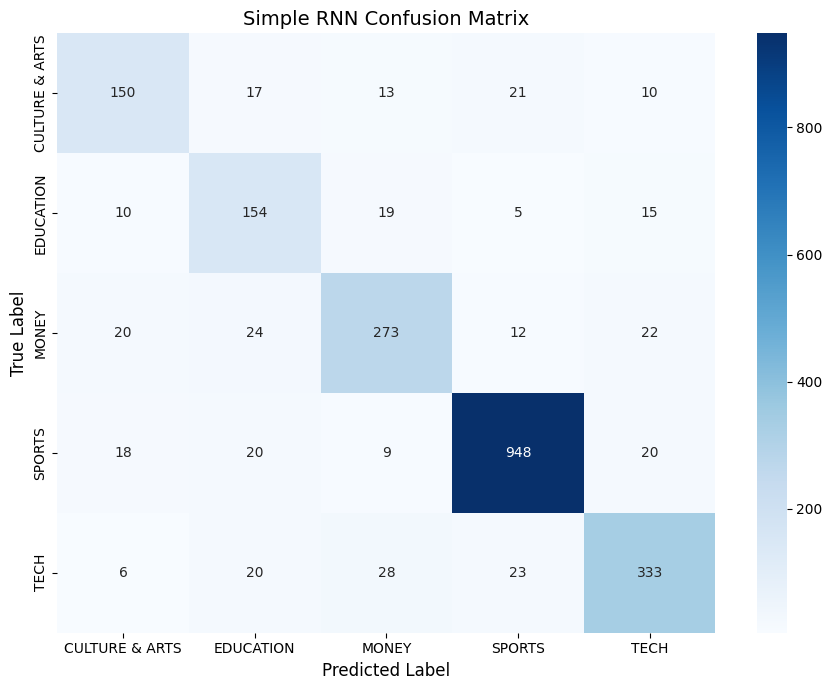

Saved confusion matrix figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model2_lstm_confusion_matrix.png


In [123]:
plot_confusion_matrix_heatmap(
    y_true=y_true_lstm,
    y_pred=y_pred_lstm,
    class_names=le.classes_,
    output_path=MODEL2_CONFUSION_FIG_PATH,
)

print(f"Saved confusion matrix figure: {MODEL2_CONFUSION_FIG_PATH}")


The LSTM confusion matrix gives a class-by-class view of the second model’s predictions. It is especially useful for checking whether the LSTM reduces confusion among minority classes or between semantically overlapping categories such as TECH and MONEY.


In [124]:
best_epoch_lstm = int(np.argmin(history_lstm.history["val_loss"])) + 1

lstm_results = {
    "model_name": "LSTM with Trainable Embedding",
    "checkpoint_path": str(MODEL2_CHECKPOINT_PATH),
    "history_path": str(HISTORY_LSTM_PATH),
    "classification_report_path": str(MODEL2_REPORT_PATH),
    "loss_figure_path": str(MODEL2_LOSS_FIG_PATH),
    "accuracy_figure_path": str(MODEL2_ACCURACY_FIG_PATH),
    "confusion_matrix_figure_path": str(MODEL2_CONFUSION_FIG_PATH),
    "training_time_seconds": float(lstm_training_seconds),
    "training_time_minutes": float(lstm_training_seconds / 60.0),
    "actual_epochs_trained": int(len(history_lstm.history["loss"])),
    "best_epoch": best_epoch_lstm,
    "best_val_loss": float(np.min(history_lstm.history["val_loss"])),
    "best_val_accuracy": float(np.max(history_lstm.history["val_accuracy"])),
    "test_accuracy": float(test_accuracy_lstm),
    "macro_precision": macro_precision_lstm,
    "macro_recall": macro_recall_lstm,
    "macro_f1": macro_f1_lstm,
    "weighted_f1": weighted_f1_lstm,
    "trainable_parameters": int(
        np.sum([np.prod(weight.shape) for weight in model_lstm.trainable_weights])
    ),
    "non_trainable_parameters": int(
        np.sum([np.prod(weight.shape) for weight in model_lstm.non_trainable_weights])
    ),
    "embedding_type": "Trainable (randomly initialised)",
    "embedding_dim": int(EMBEDDING_DIM),
    "sequence_length": int(MAX_LENGTH),
    "batch_size": int(BATCH_SIZE),
    "epoch_limit": int(EPOCHS),
    "gpu_used": get_gpu_name(),
}

display(pd.DataFrame([lstm_results]))


,model_name,checkpoint_path,history_path,classification_report_path,loss_figure_path,accuracy_figure_path,confusion_matrix_figure_path,training_time_seconds,training_time_minutes,actual_epochs_trained,...,macro_f1,weighted_f1,trainable_parameters,non_trainable_parameters,embedding_type,embedding_dim,sequence_length,batch_size,epoch_limit,gpu_used
0,LSTM with Trainable Embedding,/content/drive/MyDrive/News-dataset/checkpoint...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,40.613919,0.676899,9,...,0.79459,0.849199,673349,0,Trainable (randomly initialised),64,15,32,50,Tesla T4


This result dictionary consolidates the LSTM outputs in the same structure used for the baseline model. Using a consistent result format makes the model-comparison stage easier to assemble and reduces the chance of mixing metrics from different runs.



In [125]:
rnn_vs_lstm_comparison_df = pd.DataFrame(
    [
        {
            "model_name": simple_rnn_results["model_name"],
            "test_accuracy": simple_rnn_results["test_accuracy"],
            "macro_f1": simple_rnn_results["macro_f1"],
            "weighted_f1": simple_rnn_results["weighted_f1"],
            "best_val_accuracy": simple_rnn_results["best_val_accuracy"],
            "best_val_loss": simple_rnn_results["best_val_loss"],
            "training_time_seconds": simple_rnn_results["training_time_seconds"],
            "trainable_parameters": simple_rnn_results["trainable_parameters"],
            "embedding_type": "Trainable (randomly initialised)",
            "recurrent_layer": "SimpleRNN(64)",
        },
        {
            "model_name": lstm_results["model_name"],
            "test_accuracy": lstm_results["test_accuracy"],
            "macro_f1": lstm_results["macro_f1"],
            "weighted_f1": lstm_results["weighted_f1"],
            "best_val_accuracy": lstm_results["best_val_accuracy"],
            "best_val_loss": lstm_results["best_val_loss"],
            "training_time_seconds": lstm_results["training_time_seconds"],
            "trainable_parameters": lstm_results["trainable_parameters"],
            "embedding_type": lstm_results["embedding_type"],
            "recurrent_layer": "LSTM(64)",
        },
    ]
)

rnn_vs_lstm_comparison_df.to_csv(MODEL_COMPARISON_TABLE_PATH, index=False)

display(rnn_vs_lstm_comparison_df)
print(f"Saved comparison table: {MODEL_COMPARISON_TABLE_PATH}")


,model_name,test_accuracy,macro_f1,weighted_f1,best_val_accuracy,best_val_loss,training_time_seconds,trainable_parameters,embedding_type,recurrent_layer
0,Simple RNN with Trainable Embedding,0.822374,0.758029,0.820139,0.822374,0.559145,26.393280,648581,Trainable (randomly initialised),SimpleRNN(64)
1,LSTM with Trainable Embedding,0.848402,0.794590,0.849199,0.850228,0.537269,40.613919,673349,Trainable (randomly initialised),LSTM(64)


Saved comparison table: /content/drive/MyDrive/News-dataset/news_category_outputs/tables/model_comparison.csv


This table provides the first direct model comparison in the notebook by placing the SimpleRNN and LSTM results side by side. The same file path can later be updated to include the GloVe-based model, but at this stage it already provides a clear two-model performance summary.


The LSTM model introduces gating and a memory cell, so it is expected to model headline sequences more effectively than the simpler recurrent baseline. The next section extends this comparison further by replacing the randomly initialised trainable embedding layer with a frozen pretrained GloVe embedding matrix, which will test whether external semantic knowledge improves classification quality.


## LSTM with Pretrained GloVe Embeddings

This section examines whether a pretrained embedding space improves news headline classification beyond the two earlier models that learned their embeddings from scratch. The recurrent classifier remains an LSTM with `64` units, but the embedding layer is replaced with a frozen `glove-wiki-gigaword-50` matrix so that external semantic information can be tested directly.

In [126]:
required_names = [
    "tokenizer",
    "vocab_size",
    "X_train_pad",
    "X_test_pad",
    "y_train",
    "y_test",
    "y_test_raw",
    "NUM_CLASSES",
    "LSTM_UNITS",
    "MAX_LENGTH",
    "BATCH_SIZE",
    "EPOCHS",
    "GLOVE_EMBEDDING_DIM",
    "EMBEDDING_MATRIX_GLOVE50_PATH",
    "MODEL3_CHECKPOINT_PATH",
    "HISTORY_GLOVE_PATH",
    "MODEL3_REPORT_PATH",
    "MODEL3_LOSS_FIG_PATH",
    "MODEL3_ACCURACY_FIG_PATH",
    "MODEL3_CONFUSION_FIG_PATH",
    "save_history_to_json",
    "save_classification_report_text",
    "clear_tensorflow_memory",
    "create_standard_callbacks",
    "plot_training_history_with_references",
    "plot_confusion_matrix_heatmap",
    "get_gpu_name",
    "le",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier preprocessing and recurrent-model sections must be run first. "
        f"Missing variables, paths, or helper functions: {missing_names}"
    )

print("Prerequisite variables confirmed for the pretrained GloVe section.")


Prerequisite variables confirmed for the pretrained GloVe section.


This check confirms that the tokenized dataset, padded arrays, save paths, and reusable helper functions are already available. The pretrained embedding model depends directly on the earlier tokenizer and sequence-processing outputs because the embedding matrix must match the fitted vocabulary.


Unlike the earlier models, this model does not learn its word vectors from random initialisation. Instead, it uses pretrained GloVe vectors learned from large general English corpora. Because news headlines use formal vocabulary, `glove-wiki-gigaword-50` is an appropriate default choice. The embedding layer is frozen so that the experiment isolates the effect of pretrained semantic representations rather than mixing it with additional embedding fine-tuning.


In [127]:
import gensim.downloader as api
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def build_glove_embedding_matrix(
    tokenizer,
    glove_vectors,
    vocab_size: int,
    embedding_dim: int,
) -> tuple[np.ndarray, dict, list[str]]:
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

    words_found = 0
    words_not_found = 0
    missing_words = []

    for word, index in tokenizer.word_index.items():
        if index >= vocab_size:
            continue

        if word in glove_vectors:
            embedding_matrix[index] = glove_vectors[word]
            words_found += 1
        else:
            words_not_found += 1
            missing_words.append(word)

    total_considered = words_found + words_not_found
    coverage = (words_found / total_considered * 100.0) if total_considered else 0.0

    summary = {
        "words_found": int(words_found),
        "words_not_found": int(words_not_found),
        "coverage_percentage": float(coverage),
        "vocab_size_used": int(vocab_size),
        "embedding_dim": int(embedding_dim),
    }
    return embedding_matrix, summary, missing_words


This cell imports the GloVe loader and evaluation metrics for local independence, then defines the helper used to convert the tokenizer vocabulary into a pretrained embedding matrix. The helper also reports vocabulary coverage, which is important because any word missing from GloVe will remain a zero vector in the frozen embedding layer.


In [128]:
glove_load_start = time.time()
glove_vectors = api.load("glove-wiki-gigaword-50")
glove_load_seconds = time.time() - glove_load_start

probe_words = [
    "sports",
    "technology",
    "market",
    "education",
    "culture",
    "football",
    "iphone",
    "stock",
    "school",
    "art",
]

probe_word_df = pd.DataFrame(
    {
        "word": probe_words,
        "in_glove_vocabulary": [word in glove_vectors for word in probe_words],
    }
)

print(f"GloVe model loaded in {glove_load_seconds:.2f} seconds.")
display(probe_word_df)


[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe model loaded in 48.20 seconds.


,word,in_glove_vocabulary
0,sports,True
1,technology,True
2,market,True
3,education,True
4,culture,True
5,football,True
6,iphone,True
7,stock,True
8,school,True
9,art,True


This cell loads the `glove-wiki-gigaword-50` vectors and checks a small set of news-related probe words. These checks provide a quick qualitative confirmation that the selected embedding source is suitable for the vocabulary expected in this classification task.


In [129]:
embedding_matrix_glove50, glove_coverage_summary, missing_glove_words = build_glove_embedding_matrix(
    tokenizer=tokenizer,
    glove_vectors=glove_vectors,
    vocab_size=vocab_size,
    embedding_dim=GLOVE_EMBEDDING_DIM,
)

np.save(EMBEDDING_MATRIX_GLOVE50_PATH, embedding_matrix_glove50)

glove_coverage_df = pd.DataFrame([glove_coverage_summary])
missing_glove_words_preview = pd.DataFrame(
    {"missing_word_examples": missing_glove_words[:20]}
)

print("Embedding matrix shape:", embedding_matrix_glove50.shape)
print(f"Saved embedding matrix: {EMBEDDING_MATRIX_GLOVE50_PATH}")
display(glove_coverage_df.round(2))

if not missing_glove_words_preview.empty:
    print("Example words not found in GloVe:")
    display(missing_glove_words_preview)
else:
    print("All considered vocabulary items were found in GloVe.")


Embedding matrix shape: (10000, 50)
Saved embedding matrix: /content/drive/MyDrive/News-dataset/news_category_outputs/objects/embedding_matrix_glove50.npy


,words_found,words_not_found,coverage_percentage,vocab_size_used,embedding_dim
0,9610,389,96.11,10000,50


Example words not found in GloVe:


,missing_word_examples
0,<OOV>
1,imageblog
2,deflategate
3,nsfw
4,draymond
5,selfie
6,jameis
7,fanduel
8,draftkings
9,emoji


This cell builds the frozen embedding matrix aligned to the tokenizer vocabulary, saves it for reuse, and reports its coverage. The coverage percentage shows how much of the modelling vocabulary receives a pretrained representation, while the missing-word preview highlights which tokens fall outside the pretrained vocabulary.


In [130]:
def build_lstm_glove_model(
    embedding_matrix: np.ndarray,
    input_length: int,
    num_classes: int,
    lstm_units: int,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Embedding(
                input_dim=embedding_matrix.shape[0],
                output_dim=embedding_matrix.shape[1],
                weights=[embedding_matrix],
                input_length=input_length,
                trainable=False,
                name="glove_embedding_layer",
            ),
            tf.keras.layers.LSTM(lstm_units, name="lstm_layer"),
            tf.keras.layers.Dropout(0.3, name="dropout_layer"),
            tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer"),
        ],
        name="lstm_glove_classifier",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


This function defines the third model using a frozen pretrained embedding layer, the same LSTM layer size as Model 2, the same dropout rate, and the same five-class softmax output. Freezing the embedding layer ensures that the experiment measures the effect of pretrained word vectors rather than continued embedding learning.


In [131]:
clear_tensorflow_memory()

model_glove = build_lstm_glove_model(
    embedding_matrix=embedding_matrix_glove50,
    input_length=MAX_LENGTH,
    num_classes=NUM_CLASSES,
    lstm_units=LSTM_UNITS,
)

model_glove.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_glove_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding_layer           │ ?                      │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

The summary should show a large block of non-trainable parameters in the embedding layer because the pretrained GloVe matrix is frozen. Compared with the earlier LSTM model, the trainable parameter count should decrease because the word vectors are no longer updated during training.


In [132]:
glove_parameter_df = pd.DataFrame(
    [
        {
            "component": "Embedding matrix rows",
            "value": int(embedding_matrix_glove50.shape[0]),
        },
        {
            "component": "Embedding dimension",
            "value": int(embedding_matrix_glove50.shape[1]),
        },
        {
            "component": "Frozen embedding parameters",
            "value": int(np.prod(embedding_matrix_glove50.shape)),
        },
        {
            "component": "Trainable parameters",
            "value": int(
                np.sum([np.prod(weight.shape) for weight in model_glove.trainable_weights])
            ),
        },
        {
            "component": "Non-trainable parameters",
            "value": int(
                np.sum([np.prod(weight.shape) for weight in model_glove.non_trainable_weights])
            ),
        },
    ]
)

display(glove_parameter_df)


,component,value
0,Embedding matrix rows,10000
1,Embedding dimension,50
2,Frozen embedding parameters,500000
3,Trainable parameters,0
4,Non-trainable parameters,500000


This parameter summary makes the frozen embedding setup explicit. It shows the scale of the pretrained matrix and confirms that these embedding weights contribute to the model as non-trainable parameters rather than trainable ones.


In [133]:
glove_callbacks = create_standard_callbacks(MODEL3_CHECKPOINT_PATH)

glove_training_start = time.time()

history_glove = model_glove.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=glove_callbacks,
    verbose=1,
)

glove_training_seconds = time.time() - glove_training_start

save_history_to_json(history_glove, HISTORY_GLOVE_PATH)

print(f"Training time (seconds): {glove_training_seconds:.2f}")
print(f"Saved history: {HISTORY_GLOVE_PATH}")


Epoch 1/50
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6191 - loss: 0.9922
Epoch 1: val_loss improved from None to 0.53595, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model3_lstm_glove_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model3_lstm_glove_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7299 - loss: 0.7393 - val_accuracy: 0.8164 - val_loss: 0.5359 - learning_rate: 0.0010
Epoch 2/50
267/274 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8254 - loss: 0.5187
Epoch 2: val_loss improved from 0.53595 to 0.48895, saving model to /content/drive/MyDrive/News-dataset/checkpoints/model3_lstm_glove_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/News-dataset/checkpoints/model3_lstm_glove_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8336 - loss: 0.4947 - val_accuracy: 0.8324 - val_loss: 0.4889 - learning_rate: 0.0010
Epoch 3/50
271/274 ━━━━━━━━━━━━━━

This cell trains the pretrained-embedding model using the same padded inputs and the same optimisation settings used earlier. Since the embedding layer is frozen, the trainable part of the model is smaller than in the previous LSTM, which may affect both convergence speed and generalisation.


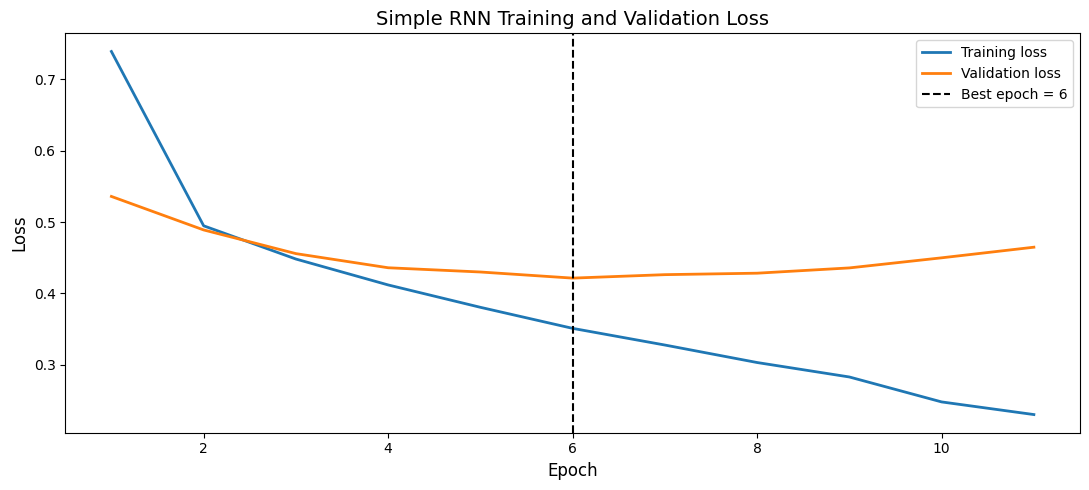

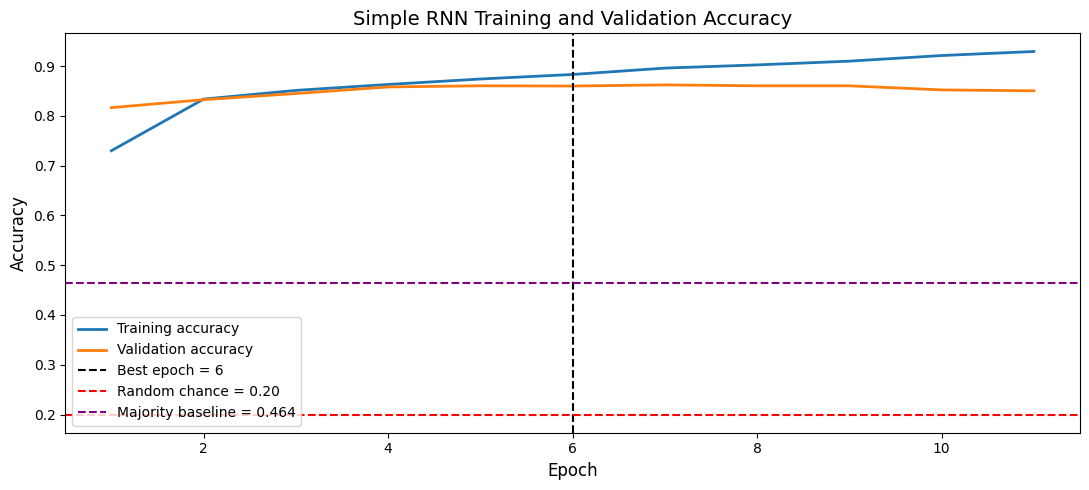

Saved loss figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model3_lstm_glove_loss_curve.png
Saved accuracy figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model3_lstm_glove_accuracy_curve.png


In [134]:
plot_training_history_with_references(
    history=history_glove,
    loss_output_path=MODEL3_LOSS_FIG_PATH,
    accuracy_output_path=MODEL3_ACCURACY_FIG_PATH,
)

print(f"Saved loss figure: {MODEL3_LOSS_FIG_PATH}")
print(f"Saved accuracy figure: {MODEL3_ACCURACY_FIG_PATH}")


These plots show the learning behaviour of the GloVe-based model under the same evaluation framework used in the earlier sections. The accuracy plot again includes the random-chance and majority-class reference lines so that the validation performance can be interpreted consistently across all three models.


In [135]:
model_glove = tf.keras.models.load_model(MODEL3_CHECKPOINT_PATH)

y_prob_glove = model_glove.predict(X_test_pad, verbose=0)
y_pred_glove = np.argmax(y_prob_glove, axis=1)
y_true_glove = y_test_raw.to_numpy()

test_accuracy_glove = accuracy_score(y_true_glove, y_pred_glove)
report_text_glove = classification_report(
    y_true_glove,
    y_pred_glove,
    target_names=le.classes_,
    digits=4,
)
report_dict_glove = classification_report(
    y_true_glove,
    y_pred_glove,
    target_names=le.classes_,
    output_dict=True,
)

macro_precision_glove = float(report_dict_glove["macro avg"]["precision"])
macro_recall_glove = float(report_dict_glove["macro avg"]["recall"])
macro_f1_glove = float(report_dict_glove["macro avg"]["f1-score"])
weighted_f1_glove = float(report_dict_glove["weighted avg"]["f1-score"])

save_classification_report_text(report_text_glove, MODEL3_REPORT_PATH)

print(f"Validation accuracy: {test_accuracy_glove:.4f}")
print(f"Macro precision: {macro_precision_glove:.4f}")
print(f"Macro recall: {macro_recall_glove:.4f}")
print(f"Macro F1-score: {macro_f1_glove:.4f}")
print(f"Weighted F1-score: {weighted_f1_glove:.4f}")
print("\nClassification report:")
print(report_text_glove)
print(f"Saved report: {MODEL3_REPORT_PATH}")


Validation accuracy: 0.8598
Macro precision: 0.8218
Macro recall: 0.8066
Macro F1-score: 0.8136
Weighted F1-score: 0.8586

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS     0.7397    0.7678    0.7535       211
     EDUCATION     0.7514    0.6847    0.7165       203
         MONEY     0.8466    0.8177    0.8319       351
        SPORTS     0.9057    0.9458    0.9253      1015
          TECH     0.8656    0.8171    0.8407       410

      accuracy                         0.8598      2190
     macro avg     0.8218    0.8066    0.8136      2190
  weighted avg     0.8584    0.8598    0.8586      2190

Saved report: /content/drive/MyDrive/News-dataset/news_category_outputs/metrics/model3_lstm_glove_classification_report.txt


This evaluation cell reloads the best GloVe-based checkpoint and computes the same classification metrics used for the earlier two models. Keeping the evaluation identical across all three models makes the final comparison section more reliable and easier to explain.


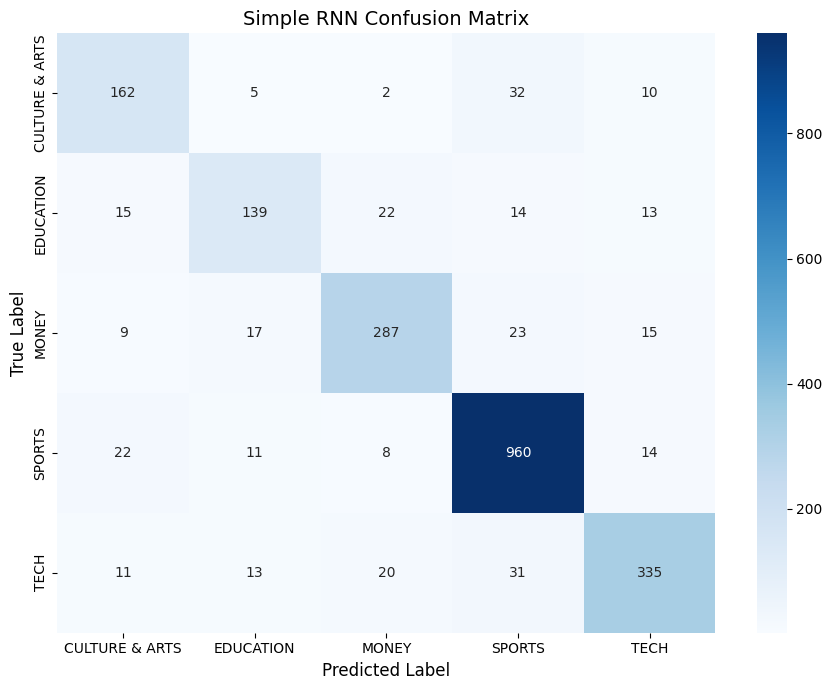

Saved confusion matrix figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/model3_lstm_glove_confusion_matrix.png


In [136]:
plot_confusion_matrix_heatmap(
    y_true=y_true_glove,
    y_pred=y_pred_glove,
    class_names=le.classes_,
    output_path=MODEL3_CONFUSION_FIG_PATH,
)

print(f"Saved confusion matrix figure: {MODEL3_CONFUSION_FIG_PATH}")


The confusion matrix for the pretrained model helps show whether the semantic information from GloVe improves class separation, particularly for categories that are conceptually close or underrepresented in the dataset.


In [137]:
best_epoch_glove = int(np.argmin(history_glove.history["val_loss"])) + 1

glove_results = {
    "model_name": "LSTM with Pretrained GloVe Embeddings",
    "checkpoint_path": str(MODEL3_CHECKPOINT_PATH),
    "history_path": str(HISTORY_GLOVE_PATH),
    "classification_report_path": str(MODEL3_REPORT_PATH),
    "loss_figure_path": str(MODEL3_LOSS_FIG_PATH),
    "accuracy_figure_path": str(MODEL3_ACCURACY_FIG_PATH),
    "confusion_matrix_figure_path": str(MODEL3_CONFUSION_FIG_PATH),
    "embedding_matrix_path": str(EMBEDDING_MATRIX_GLOVE50_PATH),
    "glove_model_name": "glove-wiki-gigaword-50",
    "glove_load_seconds": float(glove_load_seconds),
    "training_time_seconds": float(glove_training_seconds),
    "training_time_minutes": float(glove_training_seconds / 60.0),
    "actual_epochs_trained": int(len(history_glove.history["loss"])),
    "best_epoch": best_epoch_glove,
    "best_val_loss": float(np.min(history_glove.history["val_loss"])),
    "best_val_accuracy": float(np.max(history_glove.history["val_accuracy"])),
    "test_accuracy": float(test_accuracy_glove),
    "macro_precision": macro_precision_glove,
    "macro_recall": macro_recall_glove,
    "macro_f1": macro_f1_glove,
    "weighted_f1": weighted_f1_glove,
    "words_found": glove_coverage_summary["words_found"],
    "words_not_found": glove_coverage_summary["words_not_found"],
    "coverage_percentage": glove_coverage_summary["coverage_percentage"],
    "trainable_parameters": int(
        np.sum([np.prod(weight.shape) for weight in model_glove.trainable_weights])
    ),
    "non_trainable_parameters": int(
        np.sum([np.prod(weight.shape) for weight in model_glove.non_trainable_weights])
    ),
    "embedding_type": "Pretrained GloVe (frozen)",
    "embedding_dim": int(GLOVE_EMBEDDING_DIM),
    "sequence_length": int(MAX_LENGTH),
    "batch_size": int(BATCH_SIZE),
    "epoch_limit": int(EPOCHS),
    "gpu_used": get_gpu_name(),
}

display(pd.DataFrame([glove_results]))


,model_name,checkpoint_path,history_path,classification_report_path,loss_figure_path,accuracy_figure_path,confusion_matrix_figure_path,embedding_matrix_path,glove_model_name,glove_load_seconds,...,words_not_found,coverage_percentage,trainable_parameters,non_trainable_parameters,embedding_type,embedding_dim,sequence_length,batch_size,epoch_limit,gpu_used
0,LSTM with Pretrained GloVe Embeddings,/content/drive/MyDrive/News-dataset/checkpoint...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,/content/drive/MyDrive/News-dataset/news_categ...,glove-wiki-gigaword-50,48.197452,...,389,96.109611,29765,500000,Pretrained GloVe (frozen),50,15,32,50,Tesla T4


This summary table consolidates the main results of the pretrained GloVe model, including both the predictive metrics and the embedding-coverage information. These values will be used directly in the next section when all three models are compared.


At this point, the notebook contains three completed recurrent text-classification models: a SimpleRNN baseline, an LSTM with trainable embeddings, and an LSTM with frozen pretrained GloVe embeddings. The next section will compare their performance directly, examine their strengths and weaknesses, and analyse representative misclassifications.


## Model Comparison and Error Analysis

This section brings together the three completed recurrent models and compares them using the same held-out test split. The analysis focuses on predictive quality, class-wise balance, computational cost, and representative misclassifications so that the strengths and limitations of each modelling approach can be interpreted clearly.

In [138]:
required_names = [
    "X_test_pad",
    "X_test_text",
    "y_test_raw",
    "tokenizer",
    "le",
    "MAX_LENGTH",
    "simple_rnn_results",
    "lstm_results",
    "glove_results",
    "history_rnn",
    "history_lstm",
    "history_glove",
    "MODEL1_CHECKPOINT_PATH",
    "MODEL2_CHECKPOINT_PATH",
    "MODEL3_CHECKPOINT_PATH",
    "MODEL_COMPARISON_TABLE_PATH",
    "PER_CLASS_F1_TABLE_PATH",
    "MISCLASSIFIED_EXAMPLES_PATH",
    "ALL_MODELS_VAL_ACCURACY_FIG_PATH",
    "PER_CLASS_F1_FIG_PATH",
    "clean_text",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier preprocessing and three model sections must be run first. "
        f"Missing variables, paths, or helper functions: {missing_names}"
    )

print("Prerequisite variables confirmed for model comparison and error analysis.")


Prerequisite variables confirmed for model comparison and error analysis.


This check confirms that all three trained models, their saved result summaries, the held-out test split, and the required save paths are already available. The comparison section depends on outputs from every earlier modelling stage.


In [139]:
from sklearn.metrics import accuracy_score, classification_report


def plot_all_models_val_accuracy_overlay(
    history_rnn,
    history_lstm,
    history_glove,
    output_path: Path,
    random_chance: float = 0.20,
    majority_baseline: float = 0.464,
) -> None:
    rnn_epochs = range(1, len(history_rnn.history["val_accuracy"]) + 1)
    lstm_epochs = range(1, len(history_lstm.history["val_accuracy"]) + 1)
    glove_epochs = range(1, len(history_glove.history["val_accuracy"]) + 1)

    plt.figure(figsize=(11, 5))
    plt.plot(rnn_epochs, history_rnn.history["val_accuracy"], label="SimpleRNN validation accuracy", linewidth=2)
    plt.plot(lstm_epochs, history_lstm.history["val_accuracy"], label="LSTM validation accuracy", linewidth=2)
    plt.plot(glove_epochs, history_glove.history["val_accuracy"], label="LSTM + GloVe validation accuracy", linewidth=2)
    plt.axhline(random_chance, color="red", linestyle="--", linewidth=1.5, label=f"Random chance = {random_chance:.2f}")
    plt.axhline(majority_baseline, color="purple", linestyle="--", linewidth=1.5, label=f"Majority baseline = {majority_baseline:.3f}")
    plt.title("Validation Accuracy Comparison Across All Models", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Validation Accuracy", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


def build_per_class_f1_table(
    y_true: np.ndarray,
    predictions: dict[str, np.ndarray],
    class_names: np.ndarray,
) -> pd.DataFrame:
    rows = []
    for model_name, y_pred in predictions.items():
        report = classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
        for class_name in class_names:
            rows.append(
                {
                    "model_name": model_name,
                    "class_name": class_name,
                    "f1_score": float(report[class_name]["f1-score"]),
                }
            )
    return pd.DataFrame(rows)


def plot_per_class_f1_comparison(per_class_f1_df: pd.DataFrame, output_path: Path) -> None:
    pivot_df = per_class_f1_df.pivot(index="class_name", columns="model_name", values="f1_score")
    pivot_df = pivot_df.loc[list(le.classes_)]

    ax = pivot_df.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8,
    )
    ax.set_title("Per-Class F1-Score Comparison Across All Models", fontsize=14)
    ax.set_xlabel("Category", fontsize=12)
    ax.set_ylabel("F1-Score", fontsize=12)
    ax.set_ylim(0.0, 1.0)
    ax.legend(title="Model")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


def infer_error_reason(
    raw_text: str,
    true_label: str,
    predicted_label: str,
    tokenizer,
) -> str:
    cleaned_text = clean_text(raw_text)
    cleaned_tokens = cleaned_text.split()
    sequence = tokenizer.texts_to_sequences([cleaned_text])[0]
    oov_index = tokenizer.word_index.get("<OOV>")
    oov_ratio = (
        sum(token == oov_index for token in sequence) / len(sequence)
        if sequence and oov_index is not None
        else 0.0
    )

    overlap_pairs = {
        frozenset({"TECH", "MONEY"}),
        frozenset({"CULTURE & ARTS", "EDUCATION"}),
    }

    if len(cleaned_tokens) <= 4:
        return "The headline is very short, so the model has limited contextual evidence for a confident category decision."
    if oov_ratio >= 0.40:
        return "A high proportion of out-of-vocabulary or proper-noun tokens may have weakened the semantic representation of the headline."
    if frozenset({true_label, predicted_label}) in overlap_pairs:
        return "The predicted and true categories share overlapping vocabulary, which can make their semantic boundaries harder to separate."
    if predicted_label == "SPORTS" and true_label != "SPORTS":
        return "The dominant SPORTS class may have influenced the prediction when the headline evidence was comparatively weak or ambiguous."
    return "The headline likely contains category cues that are semantically mixed, so the model focused on a competing topic signal."


These helper functions prepare the final comparison plots and the misclassification analysis. The overlay plot compares validation accuracy across all three models, the per-class F1 table shows class-level balance, and the error-reason helper provides brief evidence-based hypotheses for misclassified examples.


In [140]:
model_rnn = tf.keras.models.load_model(MODEL1_CHECKPOINT_PATH)
model_lstm = tf.keras.models.load_model(MODEL2_CHECKPOINT_PATH)
model_glove = tf.keras.models.load_model(MODEL3_CHECKPOINT_PATH)

y_true_all = y_test_raw.to_numpy()

y_prob_rnn = model_rnn.predict(X_test_pad, verbose=0)
y_pred_rnn = np.argmax(y_prob_rnn, axis=1)

y_prob_lstm = model_lstm.predict(X_test_pad, verbose=0)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

y_prob_glove = model_glove.predict(X_test_pad, verbose=0)
y_pred_glove = np.argmax(y_prob_glove, axis=1)

print("All three best checkpoints have been reloaded successfully.")


All three best checkpoints have been reloaded successfully.


This cell reloads the best checkpoint from each model section and regenerates predictions on the same held-out test split. Using the same evaluation split and the same prediction workflow ensures that the final comparison is consistent across all three models.


In [141]:
model_comparison_df = pd.DataFrame(
    [
        {
            "model_name": simple_rnn_results["model_name"],
            "test_accuracy": simple_rnn_results["test_accuracy"],
            "macro_f1": simple_rnn_results["macro_f1"],
            "weighted_f1": simple_rnn_results["weighted_f1"],
            "macro_precision": simple_rnn_results["macro_precision"],
            "macro_recall": simple_rnn_results["macro_recall"],
            "best_val_accuracy": simple_rnn_results["best_val_accuracy"],
            "best_val_loss": simple_rnn_results["best_val_loss"],
            "training_time_seconds": simple_rnn_results["training_time_seconds"],
            "trainable_parameters": simple_rnn_results["trainable_parameters"],
            "non_trainable_parameters": simple_rnn_results["non_trainable_parameters"],
            "embedding_type": "Trainable (randomly initialised)",
            "recurrent_layer": "SimpleRNN(64)",
            "embedding_dim": simple_rnn_results["embedding_dim"],
            "model_complexity_level": "Lower",
        },
        {
            "model_name": lstm_results["model_name"],
            "test_accuracy": lstm_results["test_accuracy"],
            "macro_f1": lstm_results["macro_f1"],
            "weighted_f1": lstm_results["weighted_f1"],
            "macro_precision": lstm_results["macro_precision"],
            "macro_recall": lstm_results["macro_recall"],
            "best_val_accuracy": lstm_results["best_val_accuracy"],
            "best_val_loss": lstm_results["best_val_loss"],
            "training_time_seconds": lstm_results["training_time_seconds"],
            "trainable_parameters": lstm_results["trainable_parameters"],
            "non_trainable_parameters": lstm_results["non_trainable_parameters"],
            "embedding_type": lstm_results["embedding_type"],
            "recurrent_layer": "LSTM(64)",
            "embedding_dim": lstm_results["embedding_dim"],
            "model_complexity_level": "Medium",
        },
        {
            "model_name": glove_results["model_name"],
            "test_accuracy": glove_results["test_accuracy"],
            "macro_f1": glove_results["macro_f1"],
            "weighted_f1": glove_results["weighted_f1"],
            "macro_precision": glove_results["macro_precision"],
            "macro_recall": glove_results["macro_recall"],
            "best_val_accuracy": glove_results["best_val_accuracy"],
            "best_val_loss": glove_results["best_val_loss"],
            "training_time_seconds": glove_results["training_time_seconds"],
            "trainable_parameters": glove_results["trainable_parameters"],
            "non_trainable_parameters": glove_results["non_trainable_parameters"],
            "embedding_type": glove_results["embedding_type"],
            "recurrent_layer": "LSTM(64)",
            "embedding_dim": glove_results["embedding_dim"],
            "model_complexity_level": "Medium with pretrained embeddings",
        },
    ]
)

model_comparison_df = model_comparison_df.sort_values(
    by=["macro_f1", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

model_comparison_df.to_csv(MODEL_COMPARISON_TABLE_PATH, index=False)

display(model_comparison_df.round(4))
print(f"Saved comparison table: {MODEL_COMPARISON_TABLE_PATH}")


,model_name,test_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,best_val_accuracy,best_val_loss,training_time_seconds,trainable_parameters,non_trainable_parameters,embedding_type,recurrent_layer,embedding_dim,model_complexity_level
0,LSTM with Pretrained GloVe Embeddings,0.8598,0.8136,0.8586,0.8218,0.8066,0.8621,0.4214,40.4751,29765,500000,Pretrained GloVe (frozen),LSTM(64),50,Medium with pretrained embeddings
1,LSTM with Trainable Embedding,0.8484,0.7946,0.8492,0.7922,0.7987,0.8502,0.5373,40.6139,673349,0,Trainable (randomly initialised),LSTM(64),64,Medium
2,Simple RNN with Trainable Embedding,0.8224,0.7580,0.8201,0.7836,0.7471,0.8224,0.5591,26.3933,648581,0,Trainable (randomly initialised),SimpleRNN(64),64,Lower


Saved comparison table: /content/drive/MyDrive/News-dataset/news_category_outputs/tables/model_comparison.csv


This table forms the main three-model comparison required for the notebook. It combines predictive metrics, training time, parameter counts, and embedding choices so that performance can be interpreted together with model complexity rather than in isolation.


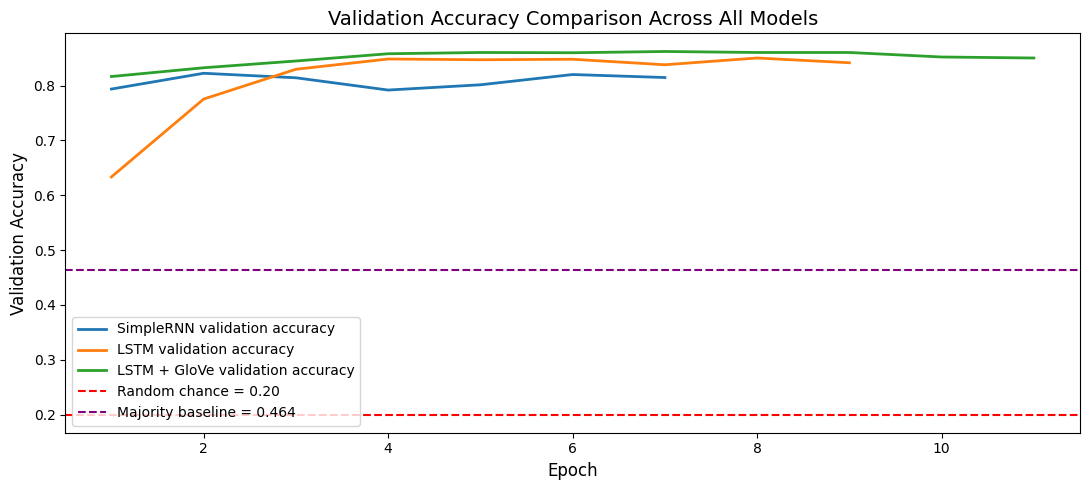

Saved validation-accuracy overlay: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/all_models_val_accuracy_overlay.png


In [142]:
plot_all_models_val_accuracy_overlay(
    history_rnn=history_rnn,
    history_lstm=history_lstm,
    history_glove=history_glove,
    output_path=ALL_MODELS_VAL_ACCURACY_FIG_PATH,
)

print(f"Saved validation-accuracy overlay: {ALL_MODELS_VAL_ACCURACY_FIG_PATH}")


This overlay plot compares the validation-accuracy trajectories of all three models in one figure. The reference lines for random chance and the majority-class baseline help show whether each model is learning beyond trivial behaviour.


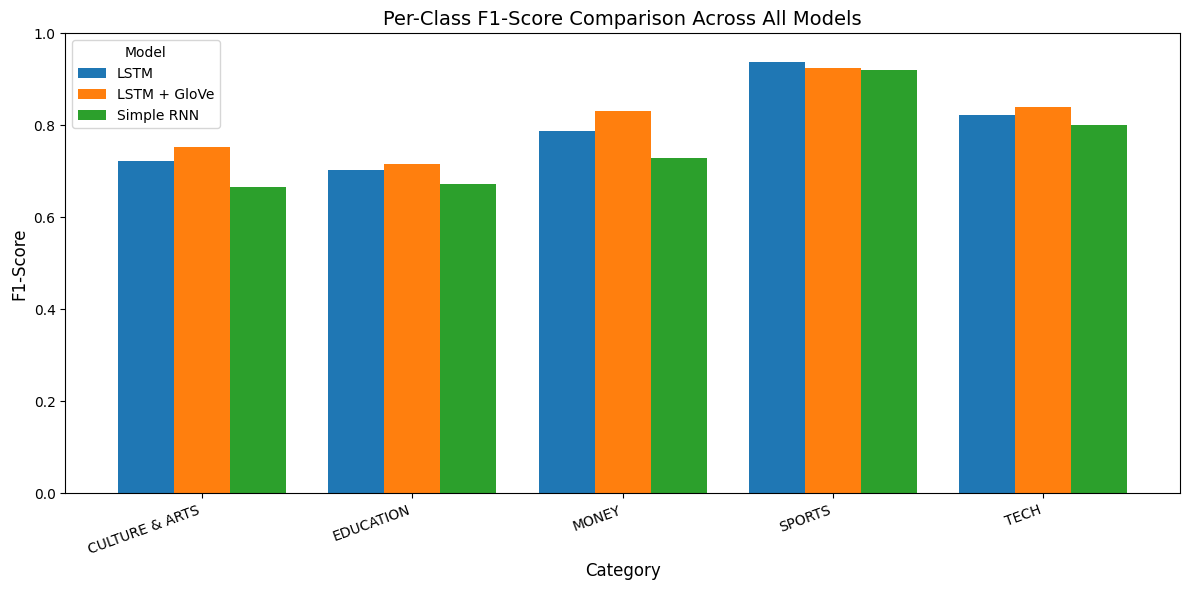

,model_name,class_name,f1_score
0,Simple RNN,CULTURE & ARTS,0.6667
1,Simple RNN,EDUCATION,0.6727
2,Simple RNN,MONEY,0.7291
3,Simple RNN,SPORTS,0.9208
4,Simple RNN,TECH,0.8010
5,LSTM,CULTURE & ARTS,0.7229
6,LSTM,EDUCATION,0.7032
7,LSTM,MONEY,0.7879
8,LSTM,SPORTS,0.9368
9,LSTM,TECH,0.8222


Saved per-class F1 table: /content/drive/MyDrive/News-dataset/news_category_outputs/tables/per_class_f1_comparison.csv
Saved per-class F1 figure: /content/drive/MyDrive/News-dataset/news_category_outputs/figures/per_class_f1_comparison.png


In [143]:
per_class_f1_df = build_per_class_f1_table(
    y_true=y_true_all,
    predictions={
        "Simple RNN": y_pred_rnn,
        "LSTM": y_pred_lstm,
        "LSTM + GloVe": y_pred_glove,
    },
    class_names=le.classes_,
)

per_class_f1_df.to_csv(PER_CLASS_F1_TABLE_PATH, index=False)
plot_per_class_f1_comparison(per_class_f1_df, PER_CLASS_F1_FIG_PATH)

display(per_class_f1_df.round(4))
print(f"Saved per-class F1 table: {PER_CLASS_F1_TABLE_PATH}")
print(f"Saved per-class F1 figure: {PER_CLASS_F1_FIG_PATH}")


This table and grouped bar chart show how each model behaves at the category level instead of only at the overall level. Because the dataset is imbalanced, the per-class F1 comparison is especially useful for judging whether minority classes are being handled fairly.


In [144]:
best_model_name = model_comparison_df.iloc[0]["model_name"]

prediction_lookup = {
    "Simple RNN with Trainable Embedding": (y_pred_rnn, y_prob_rnn),
    "LSTM with Trainable Embedding": (y_pred_lstm, y_prob_lstm),
    "LSTM with Pretrained GloVe Embeddings": (y_pred_glove, y_prob_glove),
}

best_predictions, best_probabilities = prediction_lookup[best_model_name]

misclassified_indices = np.where(best_predictions != y_true_all)[0]

misclassified_rows = []
for index in misclassified_indices:
    predicted_index = int(best_predictions[index])
    confidence = float(best_probabilities[index][predicted_index])
    true_label = le.classes_[int(y_true_all[index])]
    predicted_label = le.classes_[predicted_index]
    raw_headline = str(X_test_text.iloc[index])

    misclassified_rows.append(
        {
            "model_name": best_model_name,
            "headline_index": int(index),
            "headline_text": raw_headline,
            "true_label": true_label,
            "predicted_label": predicted_label,
            "confidence": confidence,
            "likely_reason": infer_error_reason(
                raw_text=raw_headline,
                true_label=true_label,
                predicted_label=predicted_label,
                tokenizer=tokenizer,
            ),
        }
    )

misclassified_examples_df = pd.DataFrame(misclassified_rows).sort_values(
    by="confidence",
    ascending=False,
).reset_index(drop=True)

misclassified_examples_df.to_csv(MISCLASSIFIED_EXAMPLES_PATH, index=False)

print(f"Best model selected for error analysis: {best_model_name}")
print(f"Total misclassified examples found: {len(misclassified_examples_df)}")
display(misclassified_examples_df.head(5))
print(f"Saved misclassified examples: {MISCLASSIFIED_EXAMPLES_PATH}")


Best model selected for error analysis: LSTM with Pretrained GloVe Embeddings
Total misclassified examples found: 307


,model_name,headline_index,headline_text,true_label,predicted_label,confidence,likely_reason
0,LSTM with Pretrained GloVe Embeddings,87,13 Americans Who Think They're Watching The Ol...,TECH,SPORTS,0.998837,The dominant SPORTS class may have influenced ...
1,LSTM with Pretrained GloVe Embeddings,1726,"Kaepernick, Sports, Politics, the Anthem, the ...",EDUCATION,SPORTS,0.996048,The dominant SPORTS class may have influenced ...
2,LSTM with Pretrained GloVe Embeddings,1311,"Justin Trudeau, Other World Leaders Praise Net...",TECH,SPORTS,0.995124,The dominant SPORTS class may have influenced ...
3,LSTM with Pretrained GloVe Embeddings,1423,Tim Berners-Lee Honored At London 2012 Olympic...,TECH,SPORTS,0.995052,The dominant SPORTS class may have influenced ...
4,LSTM with Pretrained GloVe Embeddings,313,Will Charters Really Try to Replace Suspension...,EDUCATION,SPORTS,0.994539,The dominant SPORTS class may have influenced ...


Saved misclassified examples: /content/drive/MyDrive/News-dataset/news_category_outputs/tables/misclassified_examples.csv


This cell selects the strongest model using the comparison table, collects its misclassified headlines, and saves them for later reporting. The displayed examples include the raw headline, the true label, the predicted label, the confidence score, and a short hypothesis about why the error may have occurred.


The comparison outputs above should be interpreted with emphasis on macro F1-score as well as overall accuracy. In an imbalanced five-class dataset, a model can achieve a strong accuracy score while still performing unevenly across categories. The per-class F1 chart and the misclassified examples therefore provide important evidence about whether improvement is broad-based or concentrated mainly in the dominant class.


Three practical improvement directions are especially relevant for this task. First, class weighting could be introduced during training so that minority categories contribute more strongly to the loss function. Second, a bidirectional LSTM or an attention-based recurrent model could capture richer contextual patterns from short headlines. Third, a larger or partially trainable pretrained embedding configuration could be explored to improve coverage for domain-specific words and named entities.


At this point, the notebook contains the full preprocessing pipeline, three recurrent text-classification models, a three-way comparison table, per-class F1 analysis, and a saved misclassification set for discussion. The remaining optional extension is a real-time prediction interface built on the same cleaning, tokenization, padding, and label-decoding workflow.


## Real-Time News Category Prediction Interface

This section provides a simple interactive interface for real-time headline classification. The interface uses the same preprocessing pipeline as the earlier models, including text cleaning, tokenization, sequence padding, and label decoding, so that the live predictions remain consistent with the training workflow used throughout the notebook.

In [145]:
required_names = [
    "tokenizer",
    "le",
    "MAX_LENGTH",
    "clean_text",
    "GUI_DIR",
    "MODEL1_CHECKPOINT_PATH",
    "MODEL2_CHECKPOINT_PATH",
    "MODEL3_CHECKPOINT_PATH",
    "simple_rnn_results",
    "lstm_results",
    "glove_results",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier preprocessing and model sections must be run first. "
        f"Missing variables, paths, or helper functions: {missing_names}"
    )

print("Prerequisite variables confirmed for the prediction interface section.")


Prerequisite variables confirmed for the prediction interface section.


This check confirms that the trained models, tokenizer, label encoder, sequence length, and cleaning function already exist. The interface can only produce valid real-time predictions if it uses exactly the same preprocessing pipeline as the training workflow.


In [146]:
!pip install gradio


This cell installs Gradio, which is used to create a lightweight browser-based prediction interface inside Colab. The package is only needed for the optional interface section and does not change the earlier modelling results.


In [147]:
import gradio as gr


interface_model_summary_df = pd.DataFrame(
    [
        {
            "model_name": simple_rnn_results["model_name"],
            "test_accuracy": simple_rnn_results["test_accuracy"],
            "macro_f1": simple_rnn_results["macro_f1"],
        },
        {
            "model_name": lstm_results["model_name"],
            "test_accuracy": lstm_results["test_accuracy"],
            "macro_f1": lstm_results["macro_f1"],
        },
        {
            "model_name": glove_results["model_name"],
            "test_accuracy": glove_results["test_accuracy"],
            "macro_f1": glove_results["macro_f1"],
        },
    ]
).sort_values(by=["macro_f1", "test_accuracy"], ascending=False).reset_index(drop=True)

best_model_name = interface_model_summary_df.iloc[0]["model_name"]

best_model_path_lookup = {
    "Simple RNN with Trainable Embedding": MODEL1_CHECKPOINT_PATH,
    "LSTM with Trainable Embedding": MODEL2_CHECKPOINT_PATH,
    "LSTM with Pretrained GloVe Embeddings": MODEL3_CHECKPOINT_PATH,
}

best_model_for_interface = tf.keras.models.load_model(best_model_path_lookup[best_model_name])

display(interface_model_summary_df.round(4))
print(f"Selected interface model: {best_model_name}")
print(f"Loaded checkpoint: {best_model_path_lookup[best_model_name]}")


,model_name,test_accuracy,macro_f1
0,LSTM with Pretrained GloVe Embeddings,0.8598,0.8136
1,LSTM with Trainable Embedding,0.8484,0.7946
2,Simple RNN with Trainable Embedding,0.8224,0.7580


Selected interface model: LSTM with Pretrained GloVe Embeddings
Loaded checkpoint: /content/drive/MyDrive/News-dataset/checkpoints/model3_lstm_glove_best.keras


This cell identifies the strongest available model using the earlier comparison results and loads its best checkpoint for interactive use. Choosing the best-performing model keeps the interface aligned with the strongest experimental outcome in the notebook.


In [148]:
def predict_news_category(headline_text: str) -> tuple[str, pd.DataFrame]:
    cleaned_text = clean_text(headline_text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post",
    )

    probabilities = best_model_for_interface.predict(padded_sequence, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = str(le.classes_[predicted_index])
    confidence = float(probabilities[predicted_index])

    probability_table = pd.DataFrame(
        {
            "category": le.classes_,
            "probability": probabilities,
            "percentage": probabilities * 100.0,
        }
    ).sort_values(by="probability", ascending=False).reset_index(drop=True)

    prediction_text = (
        f"Predicted category: {predicted_label}\n"
        f"Confidence: {confidence * 100:.2f}%\n"
        f"Cleaned headline: {cleaned_text}"
    )

    return prediction_text, probability_table.round(4)


sample_headlines = [
    "Apple unveils new artificial intelligence features for the next iPhone generation",
    "Manchester City secures dramatic late victory in title race",
    "Federal reserve signals another policy shift as inflation pressures ease",
    "University launches new scholarship programme for rural students",
    "Film festival celebrates emerging directors from across South Asia",
]

for example_headline in sample_headlines:
    prediction_text, probability_table = predict_news_category(example_headline)
    print("\nHeadline:")
    print(example_headline)
    print(prediction_text)
    display(probability_table.head(5))



Headline:
Apple unveils new artificial intelligence features for the next iPhone generation
Predicted category: TECH
Confidence: 99.03%
Cleaned headline: apple unveils new artificial intelligence feature next iphone generation


,category,probability,percentage
0,TECH,0.9903,99.034798
1,MONEY,0.0056,0.562100
2,EDUCATION,0.0017,0.174100
3,CULTURE & ARTS,0.0015,0.147600
4,SPORTS,0.0008,0.081400



Headline:
Manchester City secures dramatic late victory in title race
Predicted category: SPORTS
Confidence: 99.92%
Cleaned headline: manchester city secures dramatic late victory title race


,category,probability,percentage
0,SPORTS,0.9992,99.916298
1,TECH,0.0003,0.028300
2,CULTURE & ARTS,0.0003,0.028200
3,EDUCATION,0.0002,0.020100
4,MONEY,0.0001,0.007100



Headline:
Federal reserve signals another policy shift as inflation pressures ease
Predicted category: MONEY
Confidence: 86.30%
Cleaned headline: federal reserve signal another policy shift inflation pressure ease


,category,probability,percentage
0,MONEY,0.8630,86.299202
1,EDUCATION,0.1046,10.457200
2,TECH,0.0237,2.370500
3,SPORTS,0.0067,0.673300
4,CULTURE & ARTS,0.0020,0.199800



Headline:
University launches new scholarship programme for rural students
Predicted category: EDUCATION
Confidence: 95.97%
Cleaned headline: university launch new scholarship programme rural student


,category,probability,percentage
0,EDUCATION,0.9597,95.9674
1,MONEY,0.0161,1.6122
2,TECH,0.0126,1.2552
3,SPORTS,0.0083,0.8279
4,CULTURE & ARTS,0.0034,0.3372



Headline:
Film festival celebrates emerging directors from across South Asia
Predicted category: CULTURE & ARTS
Confidence: 97.77%
Cleaned headline: film festival celebrates emerging director across south asia


,category,probability,percentage
0,CULTURE & ARTS,0.9777,97.768501
1,TECH,0.0079,0.787700
2,EDUCATION,0.0071,0.706400
3,SPORTS,0.0039,0.394200
4,MONEY,0.0034,0.343200


This function defines the full prediction pipeline used by the interface. Each headline is cleaned, converted into a token sequence, padded to the training sequence length, passed through the selected model, and decoded back into one of the five news categories together with a probability table.


In [151]:
def gradio_predict(headline_text: str) -> tuple[str, pd.DataFrame]:
    if not headline_text or not headline_text.strip():
        empty_table = pd.DataFrame(
            {
                "category": le.classes_,
                "probability": np.zeros(len(le.classes_)),
                "percentage": np.zeros(len(le.classes_)),
            }
        )
        return "Please enter a non-empty news headline.", empty_table

    return predict_news_category(headline_text)


clickable_examples = [
    ["Apple expands semiconductor investment in new manufacturing plan"],
    ["Local school district introduces a revised digital learning policy"],
    ["National team reaches tournament final after a dramatic semifinal win"],
    ["Stock market gains as inflation data improves investor confidence"],
    ["Major museum announces a new exhibition of contemporary photography"],
    ["University announces a new teacher training initiative for rural schools"],
    ["Tech company launches a new cloud security platform for enterprises"],
    ["Olympic champion returns after injury for the world championship final"],
]

with gr.Blocks() as demo:
    gr.Markdown("## News Category Prediction Interface")
    gr.Markdown(
        "Enter a news headline to classify it into SPORTS, TECH, MONEY, "
        "CULTURE & ARTS, or EDUCATION. The example headlines below can be "
        "clicked to place their text directly into the input box."
    )

    headline_box = gr.Textbox(
        lines=3,
        placeholder="Enter a news headline here...",
        label="News Headline",
    )
    prediction_box = gr.Textbox(label="Predicted Category")
    probability_table = gr.Dataframe(label="Category Probability Table")

    submit_button = gr.Button("Predict Category")
    submit_button.click(
        fn=gradio_predict,
        inputs=headline_box,
        outputs=[prediction_box, probability_table],
    )

    gr.Examples(
        examples=clickable_examples,
        inputs=headline_box,
        label="Clickable Example Headlines",
    )


This cell wraps the prediction function in a Gradio interface so that headline classification can be tested interactively in the browser. The examples are explicitly attached to the textbox, so clicking any example headline places that text into the input field for quick testing.

In [152]:
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1de5d0917feef0e71d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Launching the interface creates a temporary browser link that can be used to test headlines in real time. The predictions remain consistent with the notebook because the interface reuses the trained model, the saved tokenizer vocabulary, the label mapping, and the same `clean_text()` function.


The interface is an optional extension, but it is useful for demonstrating that the full modelling pipeline can be applied to unseen headlines outside the static notebook evaluation. The same end-to-end flow used here can later be adapted into a standalone application or a lightweight deployment prototype.


## Final Coding Verification

This section performs a final notebook-level verification of the completed coding work. The checks focus on whether the required saved artifacts exist in Google Drive, whether the main dataset and modelling facts match the expected task configuration, and whether the core outputs needed for later report writing have already been produced.

In [153]:
required_names = [
    "DATASET_FILE",
    "CHECKPOINT_DIR",
    "FIGURE_DIR",
    "HISTORY_DIR",
    "METRIC_DIR",
    "TABLE_DIR",
    "OBJECT_DIR",
    "df",
    "tokenizer",
    "le",
    "X_train_pad",
    "X_test_pad",
    "y_train",
    "y_test",
    "simple_rnn_results",
    "lstm_results",
    "glove_results",
    "MODEL_COMPARISON_TABLE_PATH",
    "PER_CLASS_F1_TABLE_PATH",
    "MISCLASSIFIED_EXAMPLES_PATH",
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(
        "The earlier notebook sections must be run before final verification. "
        f"Missing variables, paths, or result summaries: {missing_names}"
    )

print("Prerequisite variables confirmed for final coding verification.")


Prerequisite variables confirmed for final coding verification.


This check confirms that the main dataset object, the preprocessed arrays, the saved-path variables, and the three model result summaries are all available in memory. The final verification section depends on these outputs from the earlier notebook stages.


In [154]:
required_object_files = [
    TOKENIZER_PATH,
    LABEL_ENCODER_PATH,
    X_TRAIN_PAD_PATH,
    X_TEST_PAD_PATH,
    Y_TRAIN_RAW_PATH,
    Y_TEST_RAW_PATH,
    EMBEDDING_MATRIX_GLOVE50_PATH,
]

required_checkpoint_files = [
    MODEL1_CHECKPOINT_PATH,
    MODEL2_CHECKPOINT_PATH,
    MODEL3_CHECKPOINT_PATH,
]

required_history_files = [
    HISTORY_RNN_PATH,
    HISTORY_LSTM_PATH,
    HISTORY_GLOVE_PATH,
]

required_metric_files = [
    MODEL1_REPORT_PATH,
    MODEL2_REPORT_PATH,
    MODEL3_REPORT_PATH,
]

required_table_files = [
    CLASS_DISTRIBUTION_TABLE_PATH,
    MODEL_COMPARISON_TABLE_PATH,
    PER_CLASS_F1_TABLE_PATH,
    MISCLASSIFIED_EXAMPLES_PATH,
]

required_figure_files = [
    CLASS_DISTRIBUTION_FIG_PATH,
    HEADLINE_LENGTH_FIG_PATH,
    WORDCLOUD_ALL_FIG_PATH,
    WORDCLOUD_PER_CLASS_FIG_PATH,
    TOP_WORDS_FIG_PATH,
    MODEL1_LOSS_FIG_PATH,
    MODEL1_ACCURACY_FIG_PATH,
    MODEL1_CONFUSION_FIG_PATH,
    MODEL2_LOSS_FIG_PATH,
    MODEL2_ACCURACY_FIG_PATH,
    RNN_VS_LSTM_LOSS_FIG_PATH,
    RNN_VS_LSTM_ACCURACY_FIG_PATH,
    MODEL2_CONFUSION_FIG_PATH,
    MODEL3_LOSS_FIG_PATH,
    MODEL3_ACCURACY_FIG_PATH,
    MODEL3_CONFUSION_FIG_PATH,
    ALL_MODELS_VAL_ACCURACY_FIG_PATH,
    PER_CLASS_F1_FIG_PATH,
]


def build_artifact_status_df(file_paths: list[Path], category_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "artifact_group": category_name,
                "file_name": path.name,
                "exists": path.exists(),
                "path": str(path),
            }
            for path in file_paths
        ]
    )


artifact_status_df = pd.concat(
    [
        build_artifact_status_df(required_object_files, "Objects"),
        build_artifact_status_df(required_checkpoint_files, "Checkpoints"),
        build_artifact_status_df(required_history_files, "Histories"),
        build_artifact_status_df(required_metric_files, "Metrics"),
        build_artifact_status_df(required_table_files, "Tables"),
        build_artifact_status_df(required_figure_files, "Figures"),
    ],
    ignore_index=True,
)

display(artifact_status_df)
print("All required artifacts present:", bool(artifact_status_df["exists"].all()))


,artifact_group,file_name,exists,path
0,Objects,tokenizer.pkl,True,/content/drive/MyDrive/News-dataset/news_categ...
1,Objects,label_encoder.pkl,True,/content/drive/MyDrive/News-dataset/news_categ...
2,Objects,X_train_pad.npy,True,/content/drive/MyDrive/News-dataset/news_categ...
3,Objects,X_test_pad.npy,True,/content/drive/MyDrive/News-dataset/news_categ...
4,Objects,y_train_raw.npy,True,/content/drive/MyDrive/News-dataset/news_categ...
5,Objects,y_test_raw.npy,True,/content/drive/MyDrive/News-dataset/news_categ...
6,Objects,embedding_matrix_glove50.npy,True,/content/drive/MyDrive/News-dataset/news_categ...
7,Checkpoints,model1_rnn_best.keras,True,/content/drive/MyDrive/News-dataset/checkpoint...
8,Checkpoints,model2_lstm_best.keras,True,/content/drive/MyDrive/News-dataset/checkpoint...
9,Checkpoints,model3_lstm_glove_best.keras,True,/content/drive/MyDrive/News-dataset/checkpoint...


All required artifacts present: True


This table verifies whether the expected saved outputs are present in Google Drive. It checks the main saved objects, checkpoints, histories, metric reports, tables, and figures that were created across the earlier notebook sections.


In [155]:
verification_summary_df = pd.DataFrame(
    [
        {
            "requirement": "Dataset file available",
            "status": bool(DATASET_FILE.exists()),
            "observed_value": str(DATASET_FILE),
        },
        {
            "requirement": "Final dataset row count after deduplication",
            "status": len(df) == 10947,
            "observed_value": len(df),
        },
        {
            "requirement": "Number of classes",
            "status": len(le.classes_) == 5,
            "observed_value": len(le.classes_),
        },
        {
            "requirement": "Expected class names",
            "status": set(le.classes_) == {"SPORTS", "TECH", "MONEY", "CULTURE & ARTS", "EDUCATION"},
            "observed_value": list(le.classes_),
        },
        {
            "requirement": "Padding length",
            "status": MAX_LENGTH == 15,
            "observed_value": MAX_LENGTH,
        },
        {
            "requirement": "Vocabulary cap",
            "status": NUM_WORDS == 10000,
            "observed_value": NUM_WORDS,
        },
        {
            "requirement": "Training tensor available",
            "status": X_train_pad.ndim == 2,
            "observed_value": tuple(X_train_pad.shape),
        },
        {
            "requirement": "Test tensor available",
            "status": X_test_pad.ndim == 2,
            "observed_value": tuple(X_test_pad.shape),
        },
        {
            "requirement": "One-hot training labels",
            "status": y_train.shape[1] == 5,
            "observed_value": tuple(y_train.shape),
        },
        {
            "requirement": "One-hot test labels",
            "status": y_test.shape[1] == 5,
            "observed_value": tuple(y_test.shape),
        },
        {
            "requirement": "SimpleRNN results available",
            "status": "macro_f1" in simple_rnn_results,
            "observed_value": simple_rnn_results.get("model_name"),
        },
        {
            "requirement": "LSTM results available",
            "status": "macro_f1" in lstm_results,
            "observed_value": lstm_results.get("model_name"),
        },
        {
            "requirement": "GloVe results available",
            "status": "coverage_percentage" in glove_results,
            "observed_value": glove_results.get("model_name"),
        },
        {
            "requirement": "At least three misclassified examples saved",
            "status": pd.read_csv(MISCLASSIFIED_EXAMPLES_PATH).shape[0] >= 3,
            "observed_value": int(pd.read_csv(MISCLASSIFIED_EXAMPLES_PATH).shape[0]),
        },
        {
            "requirement": "All required saved artifacts present",
            "status": bool(artifact_status_df["exists"].all()),
            "observed_value": int(artifact_status_df["exists"].sum()),
        },
    ]
)

display(verification_summary_df)
print("Overall verification passed:", bool(verification_summary_df["status"].all()))


,requirement,status,observed_value
0,Dataset file available,True,/content/drive/MyDrive/News-dataset/news_categ...
1,Final dataset row count after deduplication,True,10947
2,Number of classes,True,5
3,Expected class names,True,"[CULTURE & ARTS, EDUCATION, MONEY, SPORTS, TECH]"
4,Padding length,True,15
5,Vocabulary cap,True,10000
6,Training tensor available,True,"(8757, 15)"
7,Test tensor available,True,"(2190, 15)"
8,One-hot training labels,True,"(8757, 5)"
9,One-hot test labels,True,"(2190, 5)"


Overall verification passed: True


This table verifies the core logical requirements of the coding task rather than only the saved files. It confirms the dataset size after deduplication, the five-class setup, the padding configuration, the presence of one-hot labels, the existence of all three model summaries, and the availability of a saved misclassification set.


In [156]:
final_model_ranking_df = pd.DataFrame(
    [
        {
            "rank_candidate": simple_rnn_results["model_name"],
            "test_accuracy": simple_rnn_results["test_accuracy"],
            "macro_f1": simple_rnn_results["macro_f1"],
            "weighted_f1": simple_rnn_results["weighted_f1"],
            "embedding_type": "Trainable (randomly initialised)",
        },
        {
            "rank_candidate": lstm_results["model_name"],
            "test_accuracy": lstm_results["test_accuracy"],
            "macro_f1": lstm_results["macro_f1"],
            "weighted_f1": lstm_results["weighted_f1"],
            "embedding_type": "Trainable (randomly initialised)",
        },
        {
            "rank_candidate": glove_results["model_name"],
            "test_accuracy": glove_results["test_accuracy"],
            "macro_f1": glove_results["macro_f1"],
            "weighted_f1": glove_results["weighted_f1"],
            "embedding_type": "Pretrained GloVe (frozen)",
        },
    ]
).sort_values(by=["macro_f1", "test_accuracy"], ascending=False).reset_index(drop=True)

final_model_ranking_df.index = final_model_ranking_df.index + 1
final_model_ranking_df.index.name = "rank"

display(final_model_ranking_df.round(4))
print("Highest-ranked model for later reporting:", final_model_ranking_df.iloc[0]["rank_candidate"])


,rank_candidate,test_accuracy,macro_f1,weighted_f1,embedding_type
rank,,,,,
1,LSTM with Pretrained GloVe Embeddings,0.8598,0.8136,0.8586,Pretrained GloVe (frozen)
2,LSTM with Trainable Embedding,0.8484,0.7946,0.8492,Trainable (randomly initialised)
3,Simple RNN with Trainable Embedding,0.8224,0.7580,0.8201,Trainable (randomly initialised)


Highest-ranked model for later reporting: LSTM with Pretrained GloVe Embeddings


This final ranking table gives a compact view of the strongest overall model according to the notebook’s main evaluation metrics. It can serve as a clear reference point for later report writing and viva discussion when the final model choice needs to be justified.


The verification checks above are intended to show that the main coding requirements have already been translated into concrete notebook outputs. At this stage, the notebook contains the dataset analysis, preprocessing pipeline, three recurrent models, comparison outputs, misclassification analysis, and optional real-time interface needed for the language-task coding submission.


## Final Discussion and Interpretation

The completed notebook examined a five-class news category classification task using three recurrent neural-network configurations: a SimpleRNN with trainable embeddings, an LSTM with trainable embeddings, and an LSTM with frozen pretrained GloVe embeddings. The dataset was moderately to strongly imbalanced, with SPORTS representing 46.4% of the cleaned dataset and a max-to-min class ratio of 5.01. Because of this imbalance, macro F1-score was treated as an important evaluation metric alongside overall accuracy.

The preprocessing pipeline was designed to reflect the characteristics of short news headlines rather than long documents or informal tweets. After removing 78 duplicates, the final dataset contained 10,947 rows with no null values. A 95th-percentile sequence length of 15 words was used as the padding limit, which was sufficient to cover most headlines without introducing unnecessary padding. The tokenizer was fitted only on the training split, and the labels were encoded into five-class one-hot vectors for use with categorical cross-entropy and softmax output.


### Interpretation of the Baseline Recurrent Model

The SimpleRNN model provided a strong baseline for the task, achieving a test accuracy of `0.8224`, a macro F1-score of `0.7580`, and a weighted F1-score of `0.8201`. These results showed that even the simplest recurrent architecture was able to learn useful patterns from the padded headline sequences. The strongest class-level performance appeared in SPORTS, where the F1-score reached `0.9208`, while weaker performance appeared in categories such as CULTURE & ARTS and EDUCATION. This pattern is consistent with the class imbalance in the dataset, where the dominant SPORTS class provided the model with far more training examples than the smallest classes.

The baseline model was also the most computationally efficient of the three completed models. It trained in approximately `26.39` seconds and used `648,581` trainable parameters. This makes the SimpleRNN attractive from a simplicity and efficiency perspective, but its lower macro F1-score indicates that it was less balanced across classes than the more advanced LSTM-based alternatives.


Replacing the SimpleRNN layer with an LSTM layer improved performance across all major metrics. The LSTM model achieved a test accuracy of `0.8484`, a macro F1-score of `0.7946`, and a weighted F1-score of `0.8492`. This represented an improvement of about `0.0260` in accuracy and `0.0366` in macro F1-score over the baseline model. These gains suggest that the gated recurrent structure of the LSTM was more effective at retaining and filtering useful sequence information from the short headline texts.

The LSTM model required `673,349` trainable parameters and took about `40.61` seconds to train, so it introduced a moderate computational cost relative to the SimpleRNN baseline. However, the increase in cost was accompanied by a clear gain in classification quality, especially when the evaluation is viewed through macro F1-score rather than accuracy alone. This indicates that the additional complexity of the LSTM was justified for this task.


### Interpretation of the LSTM Model with Pretrained GloVe Embeddings

The strongest overall result was achieved by the LSTM model with frozen pretrained GloVe embeddings. This model reached a test accuracy of `0.8598`, a macro F1-score of `0.8136`, and a weighted F1-score of `0.8586`. Relative to the trainable-embedding LSTM, the GloVe model improved accuracy by about `0.0114` and macro F1-score by about `0.0190`. Relative to the baseline SimpleRNN, the improvement was larger still, at about `0.0374` in accuracy and `0.0556` in macro F1-score.

The GloVe embedding matrix achieved a vocabulary coverage of `96.11%`, with `9,610` words found and `389` words not found in the pretrained vocabulary. This high coverage helps explain why the pretrained model performed best: most of the modelling vocabulary was represented by meaningful pretrained semantic vectors before supervised training even began. The frozen-embedding model also reduced the number of trainable parameters sharply to `29,765`, although it contained `500,000` non-trainable embedding parameters. This shows that pretrained embeddings can improve quality without requiring the model to learn every word representation from scratch.


### Comparative Interpretation of the Three Models

When the three models are compared directly, a clear progression appears. The SimpleRNN model established a useful baseline, the LSTM model improved sequence modelling through gated memory, and the pretrained GloVe version produced the strongest balance between semantic representation and predictive accuracy. In the final ranking, the order was:

1. LSTM with Pretrained GloVe Embeddings
2. LSTM with Trainable Embedding
3. Simple RNN with Trainable Embedding

This ranking was consistent across accuracy, macro F1-score, and weighted F1-score. Since the dataset is imbalanced, the macro F1-score is especially important because it gives equal weight to all five classes rather than allowing the dominant SPORTS class to dominate the overall interpretation. From this perspective, the pretrained GloVe model was also the strongest.


### Error Analysis and Observed Weaknesses

The misclassification analysis showed that many of the most confident errors were predictions of SPORTS for headlines whose true class was TECH or EDUCATION. This is consistent with the dataset imbalance, since SPORTS is the dominant category and may become an attractor class when the headline signal is short, ambiguous, or semantically mixed. The saved misclassification table also suggested other common difficulties, including overlap between TECH and MONEY, short headlines with limited context, and proper-noun-heavy headlines whose meaning depends strongly on named entities rather than on common vocabulary.

Even the best model therefore still showed some vulnerability to ambiguity and class overlap. This is important because it means that higher overall accuracy does not eliminate the need for qualitative evaluation. In practical applications, these borderline cases are often the most informative for deciding how the model could be improved further.


### Model Complexity, Practical Trade-Offs, and Improvement Directions

The final results suggest a meaningful trade-off between simplicity, trainable complexity, and external semantic knowledge. The SimpleRNN model was the fastest and easiest to explain, but it produced the weakest class-balanced performance. The LSTM model introduced a moderate increase in training time and parameter count, but this complexity was justified by the improvement in both accuracy and macro F1-score. The pretrained GloVe model produced the best overall results while dramatically reducing the number of trainable parameters, which highlights the value of leveraging external embeddings in a short-text classification problem.

Several improvement directions follow naturally from these results. First, class weighting could be added during training to reduce the influence of the dominant SPORTS class and improve minority-class balance. Second, a bidirectional LSTM or attention-based recurrent model could capture richer contextual information from the headlines. Third, a larger pretrained embedding source or partially trainable embedding configuration could be explored to improve representation quality for words that are currently missing or semantically ambiguous.


## Final Conclusion

The completed coding work showed that recurrent neural-network performance improved steadily as the modelling approach became more expressive and semantically informed. The SimpleRNN model established a useful baseline, the LSTM model demonstrated the benefit of gated recurrent memory, and the LSTM with pretrained GloVe embeddings achieved the strongest final result. The best model in the notebook was therefore the pretrained GloVe-based LSTM, with a test accuracy of `0.8598`, a macro F1-score of `0.8136`, and a weighted F1-score of `0.8586`.

Overall, the results indicate that pretrained semantic representations are particularly beneficial for this news headline classification task. The final notebook therefore supports the conclusion that model architecture, embedding choice, and class-imbalance-aware evaluation all have a meaningful effect on performance, and that the GloVe-based LSTM is the most suitable final model among the three completed approaches.
